In [2]:
# Veri İşleme ve Analiz
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Anomali Tespiti
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# İstatistiksel Analiz
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

# Zaman Serisi
from statsmodels.tsa.stattools import adfuller

# Uyarı Yönetimi
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme Ayarları
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('husl')

Veri yuklendi
Satir sayisi: 353,949
Kolon sayisi: 19

Ilk 5 gozlem


,Unnamed: 0,tesisat_no_id,il,ilce,gerilim_seviyesi,marka,model,abone_grubu,son_carpan_degeri,l1,l2,l3,v1,v2,v3,t0,ri,rc,load_profile_date
0,0,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,64.67,0.01,233.75,222.62,232.08,415005.784,1019.784,2030.002,2025-08-01 00:00:00
1,1,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,60.41,0.01,233.68,222.30,230.85,415009.205,1019.784,2030.013,2025-08-01 00:15:00
2,2,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,63.23,0.01,233.48,222.11,230.98,415012.559,1019.784,2030.021,2025-08-01 00:30:00
3,3,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,65.00,0.01,235.23,222.52,232.00,415015.917,1019.784,2030.033,2025-08-01 00:45:00
4,4,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,62.46,0.01,234.70,222.52,231.78,415019.282,1019.784,2030.043,2025-08-01 01:00:00



Veri tipi ozeti
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353949 entries, 0 to 353948
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Unnamed: 0         353949 non-null  int64         
 1   tesisat_no_id      353949 non-null  object        
 2   il                 353949 non-null  object        
 3   ilce               353949 non-null  object        
 4   gerilim_seviyesi   353949 non-null  object        
 5   marka              353949 non-null  object        
 6   model              353949 non-null  object        
 7   abone_grubu        353949 non-null  object        
 8   son_carpan_degeri  353949 non-null  int64         
 9   l1                 353949 non-null  float64       
 10  l2                 353949 non-null  float64       
 11  l3                 353949 non-null  float64       
 12  v1                 278515 non-null  float64       
 13  v2                 278515 n

,count,mean,std,min,25%,50%,75%,90%,99%,max
Unnamed: 0,353949.0,176974.0,102176.419552,0.0,88487.0,176974.0,265461.0,318553.2,350408.52,353948.0
son_carpan_degeri,353949.0,178.282168,536.938121,1.0,1.0,1.0,80.0,120.0,3150.0,3150.0
l1,353949.0,2.692848,6.227561,0.0,0.0,0.105,2.2,8.002,27.5652,157.4
l2,353949.0,4.706827,9.276556,0.0,0.016,0.608,5.15,14.7,52.9752,164.19
l3,353949.0,5.368833,8.007149,0.0,0.096,1.693,7.32,16.06,38.6,132.27
v1,278515.0,190.572917,79.940922,0.0,220.54,229.96,234.3,237.82,248.06,394.0
v2,278515.0,200.46514,72.920251,0.0,223.93,230.29,234.49,238.0,251.63,405.56
v3,278515.0,209.315415,56.298138,0.0,224.67,230.29,234.38,238.0,248.55,265.1
t0,353949.0,111680.208711,178263.112673,449.616,8969.669,26010.628,102289.722,431843.2908,785763.07576,795769.237
ri,343709.0,12871.574842,43724.320536,0.0,347.599,1248.164,5406.74,34269.2248,323265.72224,330849.517



Eksik deger oranlari


,kolon,eksik_oran_yuzde
0,v1,21.312110
1,v3,21.312110
2,v2,21.312110
3,rc,2.893072
4,ri,2.893072
5,Unnamed: 0,0.000000
6,tesisat_no_id,0.000000
7,il,0.000000
8,ilce,0.000000
9,marka,0.000000


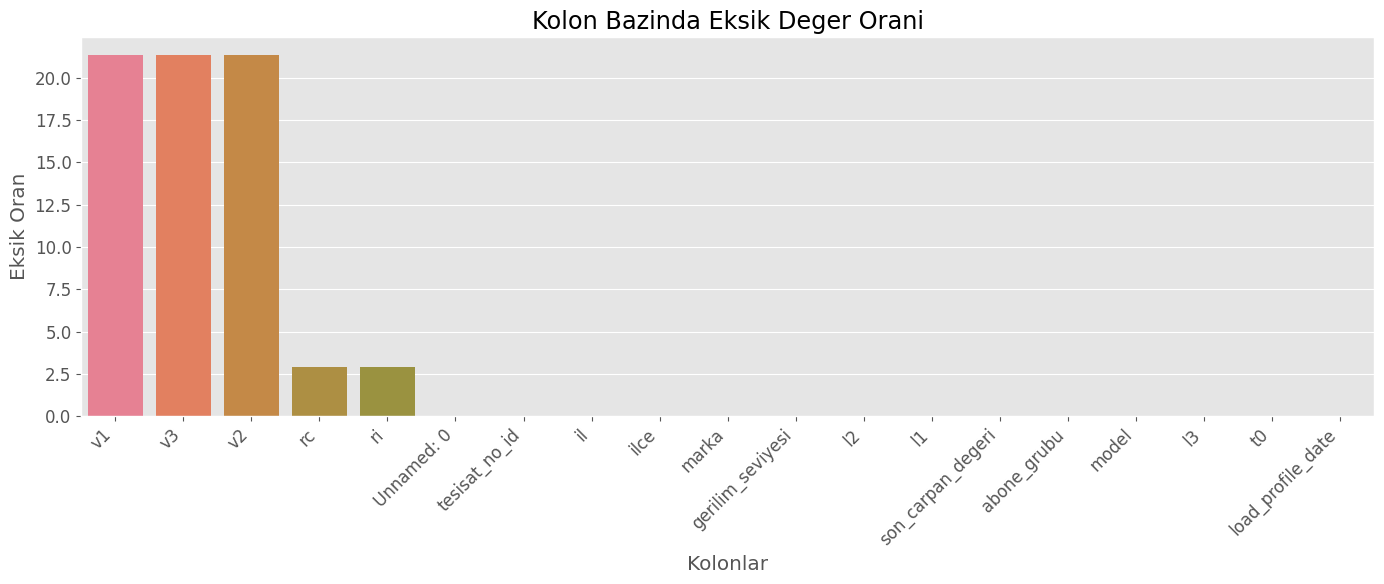


Kategorik kolon ozeti


,kolon,benzersiz_deger_sayisi
0,il,5
1,ilce,24
2,abone_grubu,10
3,gerilim_seviyesi,2
4,marka,2
5,model,5


In [3]:
# 1) Veri Yükleme ve İlk Keşif

# Veri yolu
DATA_PATH = "/workspaces/notebook-test/enerji_tuketım_verileri.csv"

# Veriyi yükle ve tarih kolonunu datetime formatına çevir
df = pd.read_csv(DATA_PATH, parse_dates=["load_profile_date"])

# Temel boyut bilgisi
print("Veri yuklendi")
print(f"Satir sayisi: {df.shape[0]:,}")
print(f"Kolon sayisi: {df.shape[1]}")

# İlk gözlem
print("\nIlk 5 gozlem")
display(df.head())

# Veri tipi ve genel bilgi
print("\nVeri tipi ozeti")
df.info()

# Sayısal kolonlar için temel istatistikler
numeric_desc = df.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.99]).T

# Datetime kolonunu ayrıca özetle (pandas sürüm uyumluluğu için)
if "load_profile_date" in df.columns and pd.api.types.is_datetime64_any_dtype(df["load_profile_date"]):
	datetime_desc = df["load_profile_date"].describe().to_frame().T
	datetime_desc.index = ["load_profile_date"]
	numeric_desc = pd.concat([numeric_desc, datetime_desc], axis=0, sort=False)

istatistik_kolonlari = ["count", "mean", "std", "min", "25%", "50%", "75%", "90%", "99%", "max"]
mevcut_kolonlar = [col for col in istatistik_kolonlari if col in numeric_desc.columns]
numeric_stats = numeric_desc[mevcut_kolonlar]

print("\nSayisal kolon istatistikleri")
display(numeric_stats)

# Eksik değer oranları
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_df = missing_pct.reset_index()
missing_df.columns = ["kolon", "eksik_oran_yuzde"]

print("\nEksik deger oranlari")
display(missing_df)

# Eksik değer oranı grafiği
plt.figure(figsize=(14, 6))
sns.barplot(data=missing_df, x="kolon", y="eksik_oran_yuzde", hue="kolon", legend=False)
plt.title("Kolon Bazinda Eksik Deger Orani")
plt.xlabel("Kolonlar")
plt.ylabel("Eksik Oran")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Kategorik kolonların benzersiz değer sayıları
categorical_cols = ["il", "ilce", "abone_grubu", "gerilim_seviyesi", "marka", "model"]
categorical_summary = df[categorical_cols].nunique(dropna=True).reset_index()
categorical_summary.columns = ["kolon", "benzersiz_deger_sayisi"]

print("\nKategorik kolon ozeti")
display(categorical_summary)

In [4]:
# 2) Veri Temizleme ve On Isleme

# Calisma kopyasi
veri = df.copy()

# Tarihsel analizler icin veri sirasi
veri = veri.sort_values(["tesisat_no_id", "load_profile_date"]).reset_index(drop=True)
veri["saat"] = veri["load_profile_date"].dt.hour

# Teknik indeks kolonu varsa kaldir
if "Unnamed: 0" in veri.columns:
    veri = veri.drop(columns=["Unnamed: 0"])

# Fiziksel olarak gecersiz degerleri NaN yap ve bayrakla
for kolon in ["l1", "l2", "l3", "t0", "ri", "rc"]:
    gecersiz_maske = veri[kolon] < 0
    veri.loc[gecersiz_maske, kolon] = np.nan

for kolon in ["v1", "v2", "v3"]:
    gecersiz_maske = (veri[kolon] <= 0) | (veri[kolon] > 500)
    veri.loc[gecersiz_maske, kolon] = np.nan

# Imputation bayrak kolonlari
impute_kolonlari = ["v1", "v2", "v3", "ri", "rc", "l1", "l2", "l3", "t0"]
for kolon in impute_kolonlari:
    veri[f"{kolon}_imputed"] = False

# Yardimci fonksiyon: tesisat bazli kisa bosluk doldurma

def kisa_bosluk_doldur(seri, limit=4):
    ileri = seri.ffill(limit=limit)
    geri = ileri.bfill(limit=limit)
    return geri

# Gerilim kolonlari: limitli ffill-bfill -> tesisat medyani -> abone grubu+saat medyani
for kolon in ["v1", "v2", "v3"]:
    baslangic_bos = veri[kolon].isna()

    veri[kolon] = veri.groupby("tesisat_no_id")[kolon].transform(lambda s: kisa_bosluk_doldur(s, limit=4))

    tesisat_medyan = veri.groupby("tesisat_no_id")[kolon].transform("median")
    veri[kolon] = veri[kolon].fillna(tesisat_medyan)

    grup_saat_medyan = veri.groupby(["abone_grubu", "saat"])[kolon].transform("median")
    veri[kolon] = veri[kolon].fillna(grup_saat_medyan)

    veri[f"{kolon}_imputed"] = baslangic_bos & veri[kolon].notna()

# Reaktif kolonlar: tesisat medyani -> global medyan
for kolon in ["ri", "rc"]:
    baslangic_bos = veri[kolon].isna()

    tesisat_medyan = veri.groupby("tesisat_no_id")[kolon].transform("median")
    veri[kolon] = veri[kolon].fillna(tesisat_medyan)

    global_medyan = veri[kolon].median()
    veri[kolon] = veri[kolon].fillna(global_medyan)

    veri[f"{kolon}_imputed"] = baslangic_bos & veri[kolon].notna()

# Kritik kolonlar: sadece kisa bosluklar icin lineer interpolasyon (uzun bosluklar kalir)
for kolon in ["l1", "l2", "l3", "t0"]:
    baslangic_bos = veri[kolon].isna()

    veri[kolon] = veri.groupby("tesisat_no_id")[kolon].transform(
        lambda s: s.interpolate(method="linear", limit=4, limit_direction="both")
    )

    veri[f"{kolon}_imputed"] = baslangic_bos & veri[kolon].notna()

# Temel turetilmis degiskenler (2. adimda aykiri analizi icin)
veri["ort_akim"] = veri[["l1", "l2", "l3"]].mean(axis=1)
veri["faz_dengesizligi"] = veri[["l1", "l2", "l3"]].max(axis=1) - veri[["l1", "l2", "l3"]].min(axis=1)
veri["aktif_tuketim_farki"] = veri.groupby("tesisat_no_id")["t0"].diff()

# Robust aykiri deger tespiti: tesisat + saat bazinda MAD

def robust_zscore(seri):
    medyan = np.nanmedian(seri)
    sapma = np.nanmedian(np.abs(seri - medyan))
    if np.isnan(sapma) or sapma == 0:
        return pd.Series(np.zeros(len(seri)), index=seri.index)
    return 0.6745 * (seri - medyan) / sapma

aykiri_kolonlari = ["ort_akim", "faz_dengesizligi", "aktif_tuketim_farki", "v1", "v2", "v3", "ri", "rc"]
for kolon in aykiri_kolonlari:
    z_kolon = f"{kolon}_robust_z"
    flag_kolon = f"{kolon}_outlier"

    veri[z_kolon] = veri.groupby(["tesisat_no_id", "saat"])[kolon].transform(robust_zscore)
    veri[flag_kolon] = veri[z_kolon].abs() > 3.5

outlier_flag_kolonlari = [f"{kolon}_outlier" for kolon in aykiri_kolonlari]
veri["outlier_any"] = veri[outlier_flag_kolonlari].any(axis=1)

# Ozet tablolar
missing_before = (df.isna().mean() * 100).round(2)
missing_after = (veri[[c for c in df.columns if c in veri.columns]].isna().mean() * 100).round(2)

temizlik_ozet = pd.DataFrame({
    "eksik_oran_once": missing_before,
    "eksik_oran_sonra": missing_after
}).fillna(0).sort_values("eksik_oran_once", ascending=False)

impute_ozet = pd.Series({
    kolon: int(veri[f"{kolon}_imputed"].sum()) for kolon in impute_kolonlari
}).rename("doldurulan_kayit_sayisi").to_frame()

outlier_ozet = pd.Series({
    kolon: int(veri[f"{kolon}_outlier"].sum()) for kolon in aykiri_kolonlari
}).rename("aykiri_kayit_sayisi").to_frame()

print("Veri temizleme ve on isleme tamamlandi")
print(f"Toplam kayit: {len(veri):,}")
print(f"Herhangi bir aykiri isaretlenen kayit: {int(veri['outlier_any'].sum()):,}")

print("\nEksik deger oranlari (once-sonra)")
display(temizlik_ozet)

print("\nDoldurulan kayit ozetleri")
display(impute_ozet)

print("\nAykiri kayit ozetleri")
display(outlier_ozet)

# Sonraki adimlar icin temiz veri kopyasi
df_clean = veri.copy()

# Kisa not
print("\nNot")
print("Gerilim kolonlari hiyerarsik yaklasim ile dolduruldu: kisa bosluk, tesisat medyani, grup-saat medyani")
print("Kritik olcumlerde uzun bosluklar korunarak veri uydurma riski azaltildi")
print("Aykiri kayitlar silinmedi, operasyonel analiz icin etiketlendi")

Veri temizleme ve on isleme tamamlandi
Toplam kayit: 353,949
Herhangi bir aykiri isaretlenen kayit: 71,451

Eksik deger oranlari (once-sonra)


,eksik_oran_once,eksik_oran_sonra
v2,21.31,0.0
v1,21.31,0.0
v3,21.31,0.0
ri,2.89,0.0
rc,2.89,0.0
Unnamed: 0,0.00,0.0
abone_grubu,0.00,0.0
gerilim_seviyesi,0.00,0.0
il,0.00,0.0
l1,0.00,0.0



Doldurulan kayit ozetleri


,doldurulan_kayit_sayisi
v1,79842
v2,78379
v3,75492
ri,10240
rc,10240
l1,0
l2,0
l3,0
t0,0



Aykiri kayit ozetleri


,aykiri_kayit_sayisi
ort_akim,26113
faz_dengesizligi,24125
aktif_tuketim_farki,26137
v1,6312
v2,6437
v3,5018
ri,15513
rc,8613



Not
Gerilim kolonlari hiyerarsik yaklasim ile dolduruldu: kisa bosluk, tesisat medyani, grup-saat medyani
Kritik olcumlerde uzun bosluklar korunarak veri uydurma riski azaltildi
Aykiri kayitlar silinmedi, operasyonel analiz icin etiketlendi


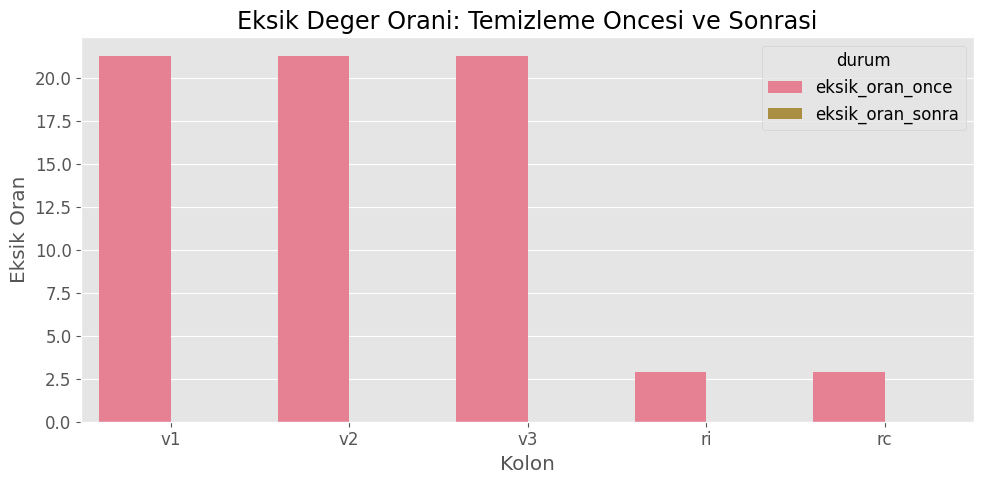

Robust ve IQR aykiri karsilastirma tablosu


,kolon,robust_sayi,iqr_sayi,kesisim_sayi,robust_oran,iqr_oran
2,aktif_tuketim_farki,26137,35723,3029,7.38,10.09
0,ort_akim,26113,37327,3637,7.38,10.55
1,faz_dengesizligi,24125,22458,1050,6.82,6.34
6,ri,15513,63070,3232,4.38,17.82
7,rc,8613,43938,0,2.43,12.41
4,v2,6437,53895,4728,1.82,15.23
3,v1,6312,64279,4556,1.78,18.16
5,v3,5018,48687,2949,1.42,13.76


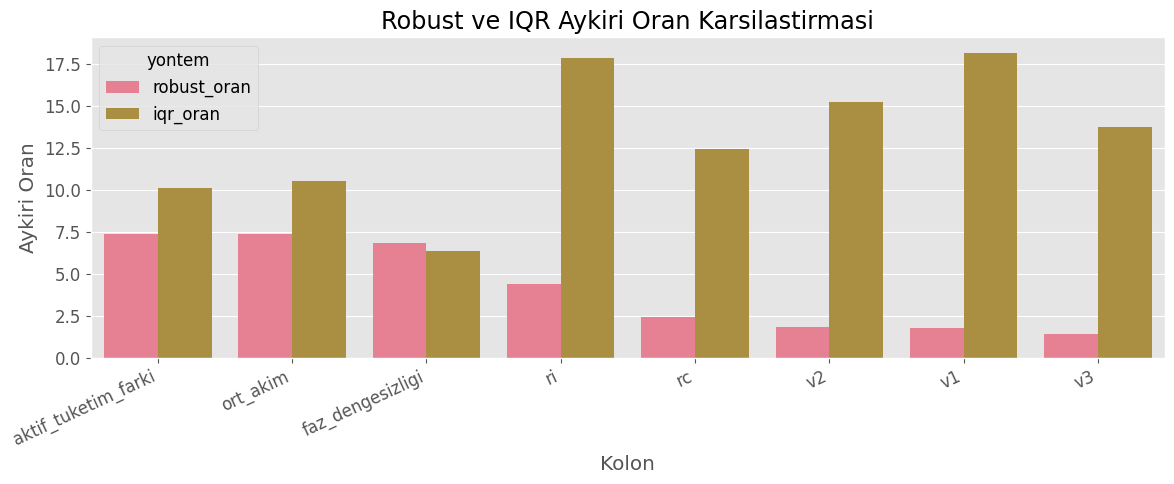

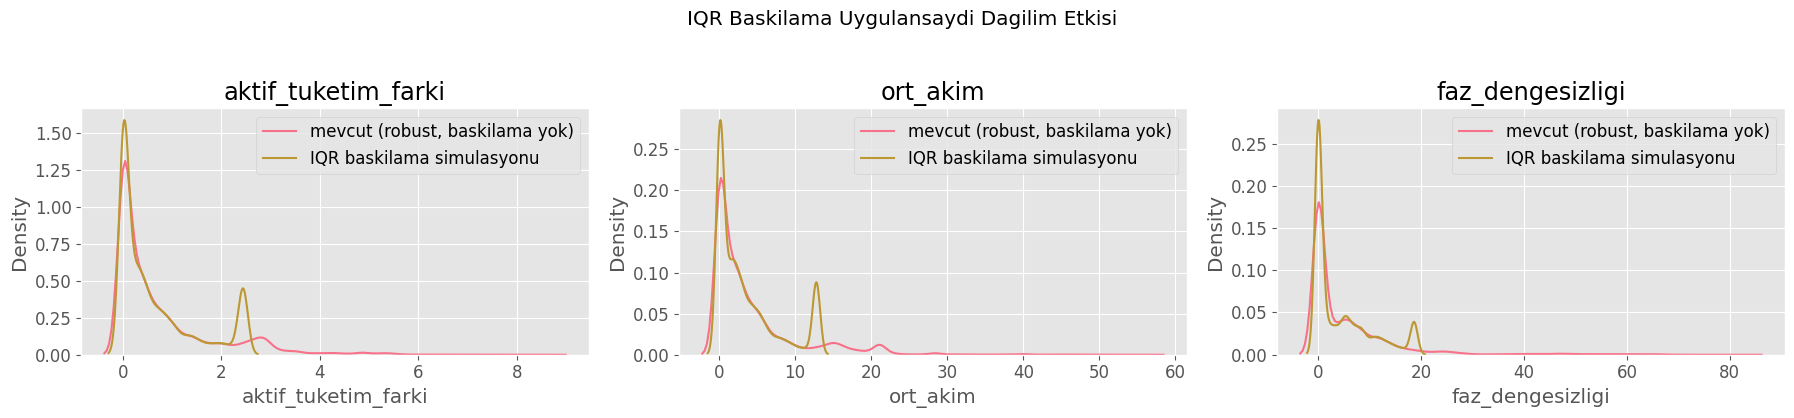

IQR baskilama simulasyonu etkisi


,kolon,p99_orijinal,p99_iqr_baskili,max_orijinal,max_iqr_baskili
0,aktif_tuketim_farki,4.863,2.443,65.964,2.443
1,ort_akim,28.287,12.808,140.097,12.808
2,faz_dengesizligi,53.070,18.703,114.190,18.703


In [5]:
# 2.1) Temizleme etkisi ve Robust vs IQR karsilastirma

analiz_df = df_clean.copy()

# Eksik deger etkisi (once-sonra)
missing_kolonlari = ["v1", "v2", "v3", "ri", "rc"]
missing_karsilastirma = temizlik_ozet.loc[missing_kolonlari].reset_index().rename(columns={"index": "kolon"})

plt.figure(figsize=(10, 5))
missing_plot = missing_karsilastirma.melt(
    id_vars="kolon",
    value_vars=["eksik_oran_once", "eksik_oran_sonra"],
    var_name="durum",
    value_name="eksik_oran"
)
sns.barplot(data=missing_plot, x="kolon", y="eksik_oran", hue="durum")
plt.title("Eksik Deger Orani: Temizleme Oncesi ve Sonrasi")
plt.xlabel("Kolon")
plt.ylabel("Eksik Oran")
plt.tight_layout()
plt.show()

# Robust ve IQR aykiri karsilastirmasi
karsi_kolonlar = ["ort_akim", "faz_dengesizligi", "aktif_tuketim_farki", "v1", "v2", "v3", "ri", "rc"]

karsi_satirlari = []
iqr_maskeleri = {}

for kolon in karsi_kolonlar:
    seri = analiz_df[kolon]

    robust_mask = analiz_df[f"{kolon}_outlier"].fillna(False)

    q1 = seri.quantile(0.25)
    q3 = seri.quantile(0.75)
    iqr = q3 - q1
    alt_sinir = q1 - 1.5 * iqr
    ust_sinir = q3 + 1.5 * iqr
    iqr_mask = (seri < alt_sinir) | (seri > ust_sinir)
    iqr_mask = iqr_mask.fillna(False)

    iqr_maskeleri[kolon] = iqr_mask

    robust_sayi = int(robust_mask.sum())
    iqr_sayi = int(iqr_mask.sum())
    kesisim_sayi = int((robust_mask & iqr_mask).sum())

    karsi_satirlari.append({
        "kolon": kolon,
        "robust_sayi": robust_sayi,
        "iqr_sayi": iqr_sayi,
        "kesisim_sayi": kesisim_sayi,
        "robust_oran": round(100 * robust_sayi / len(analiz_df), 2),
        "iqr_oran": round(100 * iqr_sayi / len(analiz_df), 2)
    })

robust_iqr_ozet = pd.DataFrame(karsi_satirlari).sort_values("robust_sayi", ascending=False)

print("Robust ve IQR aykiri karsilastirma tablosu")
display(robust_iqr_ozet)

karsi_plot = robust_iqr_ozet.melt(
    id_vars="kolon",
    value_vars=["robust_oran", "iqr_oran"],
    var_name="yontem",
    value_name="aykiri_oran"
)

plt.figure(figsize=(12, 5))
sns.barplot(data=karsi_plot, x="kolon", y="aykiri_oran", hue="yontem")
plt.title("Robust ve IQR Aykiri Oran Karsilastirmasi")
plt.xlabel("Kolon")
plt.ylabel("Aykiri Oran")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# IQR baskilama olsaydi dagilim etkisi (simulasyon)
inceleme_kolonlari = ["aktif_tuketim_farki", "ort_akim", "faz_dengesizligi"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for idx, kolon in enumerate(inceleme_kolonlari):
    seri = analiz_df[kolon].dropna()
    q1 = seri.quantile(0.25)
    q3 = seri.quantile(0.75)
    iqr = q3 - q1
    alt_sinir = q1 - 1.5 * iqr
    ust_sinir = q3 + 1.5 * iqr

    capped = seri.clip(lower=alt_sinir, upper=ust_sinir)

    orijinal_ornek = seri.sample(min(40000, len(seri)), random_state=42)
    capped_ornek = capped.sample(min(40000, len(capped)), random_state=42)

    sns.kdeplot(orijinal_ornek, ax=axes[idx], label="mevcut (robust, baskilama yok)", fill=False)
    sns.kdeplot(capped_ornek, ax=axes[idx], label="IQR baskilama simulasyonu", fill=False)
    axes[idx].set_title(kolon)
    axes[idx].legend()

plt.suptitle("IQR Baskilama Uygulansaydi Dagilim Etkisi", y=1.04)
plt.tight_layout()
plt.show()

# Simulasyon ozet tablosu
simulasyon_ozet = []
for kolon in inceleme_kolonlari:
    seri = analiz_df[kolon].dropna()
    q1 = seri.quantile(0.25)
    q3 = seri.quantile(0.75)
    iqr = q3 - q1
    alt_sinir = q1 - 1.5 * iqr
    ust_sinir = q3 + 1.5 * iqr
    capped = seri.clip(lower=alt_sinir, upper=ust_sinir)

    simulasyon_ozet.append({
        "kolon": kolon,
        "p99_orijinal": round(seri.quantile(0.99), 3),
        "p99_iqr_baskili": round(capped.quantile(0.99), 3),
        "max_orijinal": round(seri.max(), 3),
        "max_iqr_baskili": round(capped.max(), 3)
    })

simulasyon_ozet_df = pd.DataFrame(simulasyon_ozet)
print("IQR baskilama simulasyonu etkisi")
display(simulasyon_ozet_df)

In [6]:
# 2.2) Kisa yorum notu

robust_toplam = int(analiz_df["outlier_any"].sum())
iqr_any = pd.Series(False, index=analiz_df.index)
for kolon in karsi_kolonlar:
    iqr_any = iqr_any | iqr_maskeleri[kolon]
iqr_toplam = int(iqr_any.sum())

print("Not")
print("Eksik degerler hiyerarsik yaklasim ile tamamlandi ve gerilim/reaktif kolonlarda bosluklar kapatildi")
print("Aykiri kayitlar silinmedi, etiketlenerek operasyonel inceleme icin korundu")
print(f"Robust yaklasim ile isaretlenen toplam kayit: {robust_toplam:,}")
print(f"Global IQR ile isaretlenecek toplam kayit: {iqr_toplam:,}")
print("IQR baskilama simulasyonu, dagilim kuyruklarini daha sert kestigi icin enerji davranisini fazla duzlestirebilir")

Not
Eksik degerler hiyerarsik yaklasim ile tamamlandi ve gerilim/reaktif kolonlarda bosluklar kapatildi
Aykiri kayitlar silinmedi, etiketlenerek operasyonel inceleme icin korundu
Robust yaklasim ile isaretlenen toplam kayit: 71,451
Global IQR ile isaretlenecek toplam kayit: 170,238
IQR baskilama simulasyonu, dagilim kuyruklarini daha sert kestigi icin enerji davranisini fazla duzlestirebilir


In [7]:
# 2.3) Eksik kalan kalite kontrolleri ve analize hazir veri

# Temiz veri uzerinden kalite zenginlestirme
df_step2 = df_clean.copy()

# Zaman degiskenleri (2. adim gereksinimi)
df_step2["gun"] = df_step2["load_profile_date"].dt.day
df_step2["hafta_gunu"] = df_step2["load_profile_date"].dt.dayofweek
df_step2["hafta_no"] = df_step2["load_profile_date"].dt.isocalendar().week.astype(int)
df_step2["ay"] = df_step2["load_profile_date"].dt.month

# Negatif/sifir tuketim kontrolleri
df_step2["t0_sifir_veya_negatif_flag"] = df_step2["t0"] <= 0
df_step2["aktif_tuketim_farki_negatif_flag"] = df_step2["aktif_tuketim_farki"] < 0
df_step2["aktif_tuketim_farki_sifir_flag"] = df_step2["aktif_tuketim_farki"].eq(0)

# Kritik alanlarda hala eksik kalan kayitlar
df_step2["kritik_eksik_flag"] = df_step2[["l1", "l2", "l3", "t0", "load_profile_date"]].isna().any(axis=1)

# 2. adimin ozet kalite tablosu
kalite_ozet = pd.DataFrame(
    {
        "metrik": [
            "t0 sifir veya negatif",
            "aktif tuketim farki negatif",
            "aktif tuketim farki sifir",
            "kritik alan eksik",
            "robust aykiri (outlier_any)"
        ],
        "kayit_sayisi": [
            int(df_step2["t0_sifir_veya_negatif_flag"].sum()),
            int(df_step2["aktif_tuketim_farki_negatif_flag"].sum()),
            int(df_step2["aktif_tuketim_farki_sifir_flag"].sum()),
            int(df_step2["kritik_eksik_flag"].sum()),
            int(df_step2["outlier_any"].sum())
        ]
    }
)
kalite_ozet["oran_yuzde"] = (100 * kalite_ozet["kayit_sayisi"] / len(df_step2)).round(2)

# Analize hazir veri: fiziksel olarak gecersiz veya kritik eksik kayitlar disarida
analiz_maskesi = (
    ~df_step2["t0_sifir_veya_negatif_flag"]
    & ~df_step2["kritik_eksik_flag"]
)

df_model = df_step2.loc[analiz_maskesi].copy()
df_clean = df_step2.copy()

print("2. adim tamamlama ozeti")
print(f"Temiz veri satir sayisi: {len(df_clean):,}")
print(f"Analize hazir veri satir sayisi: {len(df_model):,}")

display(kalite_ozet)

print("Not")
print("Robust yontem ana aykiri yaklasimi olarak korundu")
print("IQR sonuclari sadece karsilastirma amacli tutuldu")

2. adim tamamlama ozeti
Temiz veri satir sayisi: 353,949
Analize hazir veri satir sayisi: 353,949


,metrik,kayit_sayisi,oran_yuzde
0,t0 sifir veya negatif,0,0.00
1,aktif tuketim farki negatif,0,0.00
2,aktif tuketim farki sifir,17376,4.91
3,kritik alan eksik,0,0.00
4,robust aykiri (outlier_any),71451,20.19


Not
Robust yontem ana aykiri yaklasimi olarak korundu
IQR sonuclari sadece karsilastirma amacli tutuldu


In [8]:
# 2.4) Zaman indeksi ve frekans ayari

# Zaman serisi calismasi icin tarih indeksli gorunum
df_ts = df_model.copy()
df_ts = df_ts.sort_values(["tesisat_no_id", "load_profile_date"])
df_ts = df_ts.set_index("load_profile_date")

# Frekans kontrolu: tesisat bazinda ardisk zaman farklarinin modu
zaman_farki = (
    df_model
    .sort_values(["tesisat_no_id", "load_profile_date"])
    .groupby("tesisat_no_id")["load_profile_date"]
    .diff()
    .dropna()
)

frekans_dagilimi = zaman_farki.value_counts().head(5)
baskin_frekans = frekans_dagilimi.index[0] if len(frekans_dagilimi) > 0 else pd.Timedelta(minutes=15)

# Modelleme icin beklenen frekans (15 dakika)
def frekans_label(td):
    dakika = int(td.total_seconds() // 60)
    return f"{dakika}T"

model_frekansi = frekans_label(baskin_frekans)

# Yonetim gorunumu: haftalik ozet
haftalik_ozet = (
    df_ts.groupby("tesisat_no_id")
    .resample("W")
    .agg(
        ort_akim=("ort_akim", "mean"),
        ort_gerilim=("v1", "mean"),
        aktif_tuketim=("aktif_tuketim_farki", "sum"),
        aykiri_sayisi=("outlier_any", "sum")
    )
    .reset_index()
)

print("Zaman indeksi ayarlandi")
print(f"Baskin gozlem frekansi: {baskin_frekans}")
print(f"Model frekansi: {model_frekansi}")
print(f"Haftalik ozet satir sayisi: {len(haftalik_ozet):,}")

print("\nFrekans dagilimi (ilk 5)")
display(frekans_dagilimi.to_frame("adet"))

print("\nHaftalik ozet ornek")
display(haftalik_ozet.head())

print("\nNot")
print("Anomali tespiti operasyonel davranis icin 15 dakikalik frekansta surdurulecek")
print("Yonetim ozetleri icin haftalik gorunumler tutulacak")

Zaman indeksi ayarlandi
Baskin gozlem frekansi: 0 days 00:15:00
Model frekansi: 15T
Haftalik ozet satir sayisi: 707

Frekans dagilimi (ilk 5)


,adet
load_profile_date,
0 days 00:15:00,333317
0 days 01:00:00,18875
0 days 00:08:00,110
0 days 00:04:00,109
0 days 00:11:00,108



Haftalik ozet ornek


,tesisat_no_id,load_profile_date,ort_akim,ort_gerilim,aktif_tuketim,aykiri_sayisi
0,0a6bce9bc9a945c0acbd8c048cb1e0a0,2025-08-03,0.064829,230.416172,3.069,53
1,0a6bce9bc9a945c0acbd8c048cb1e0a0,2025-08-10,0.100304,231.183750,11.321,44
2,0a6bce9bc9a945c0acbd8c048cb1e0a0,2025-08-17,0.118258,230.440919,13.391,70
3,0a6bce9bc9a945c0acbd8c048cb1e0a0,2025-08-24,0.102949,230.398202,11.603,68
4,0a6bce9bc9a945c0acbd8c048cb1e0a0,2025-08-31,0.072432,232.093160,7.947,102



Not
Anomali tespiti operasyonel davranis icin 15 dakikalik frekansta surdurulecek
Yonetim ozetleri icin haftalik gorunumler tutulacak


In [9]:
# 3) Feature Engineering (Turetilmis Degiskenler)

# 3. adim icin temiz veri kopyasi
df_fe = df_model.copy()

# Temel turetilmis degiskenler
df_fe["ort_akim"] = df_fe[["l1", "l2", "l3"]].mean(axis=1)
df_fe["ort_gerilim"] = df_fe[["v1", "v2", "v3"]].mean(axis=1)
df_fe["faz_dengesizligi"] = df_fe[["l1", "l2", "l3"]].max(axis=1) - df_fe[["l1", "l2", "l3"]].min(axis=1)
df_fe["aktif_tuketim_farki"] = df_fe.groupby("tesisat_no_id")["t0"].diff()

# Gerilim sapma orani (230V nominal referans)
nominal_gerilim = 230
df_fe["gerilim_sapma_orani"] = (
    df_fe[["v1", "v2", "v3"]]
    .sub(nominal_gerilim)
    .abs()
    .mean(axis=1)
    .div(nominal_gerilim)
    * 100
)

# Akim-tuketim tutarsizlik gostergesi (PDF tanimi: ardiskik tuketim farki)
df_fe["akim_tuketim_tutarsizlik"] = df_fe["aktif_tuketim_farki"]

# Saat dilimi kategorisi
saat = df_fe["load_profile_date"].dt.hour
kosullar = [
    (saat >= 8) & (saat < 17),
    ((saat >= 6) & (saat < 8)) | ((saat >= 17) & (saat < 22))
]
secimler = ["Mesai", "Gunduz"]
df_fe["saat_dilimi"] = np.select(kosullar, secimler, default="Gece")

# Haftalik yonetim gorunumu (yalnizca haftalik)
haftalik_yonetim = (
    df_fe
    .set_index("load_profile_date")
    .groupby("il")
    .resample("W")
    .agg(
        tesisat_sayisi=("tesisat_no_id", "nunique"),
        aktif_tuketim_toplam=("aktif_tuketim_farki", "sum"),
        ort_gerilim_sapma=("gerilim_sapma_orani", "mean"),
        ort_faz_dengesizligi=("faz_dengesizligi", "mean"),
        aykiri_oran=("outlier_any", "mean")
    )
    .reset_index()
)
haftalik_yonetim["aykiri_oran"] = (haftalik_yonetim["aykiri_oran"] * 100).round(2)

# Feature ozet tablosu
feature_ozet = pd.DataFrame({
    "feature": [
        "ort_akim",
        "ort_gerilim",
        "faz_dengesizligi",
        "aktif_tuketim_farki",
        "gerilim_sapma_orani",
        "akim_tuketim_tutarsizlik",
        "saat_dilimi"
    ],
    "aciklama": [
        "Uc faz akim ortalamasi",
        "Uc faz gerilim ortalamasi",
        "Fazlar arasi akim farki",
        "Ardisik tuketim farki",
        "Nominal 230V'a ortalama sapma orani",
        "Akim-tuketim tutarsizlik gostergesi",
        "Gece/Gunduz/Mesai zaman etiketi"
    ]
})

print("Feature engineering tamamlandi")
print(f"Feature uygulanmis satir sayisi: {len(df_fe):,}")
print(f"Haftalik yonetim gorunumu satir sayisi: {len(haftalik_yonetim):,}")

print("\nUretilen feature listesi")
display(feature_ozet)

print("\nHaftalik yonetim gorunumu ornek")
display(haftalik_yonetim.head())

# Sonraki adimlar icin guncel veri
df_model = df_fe.copy()

Feature engineering tamamlandi
Feature uygulanmis satir sayisi: 353,949
Haftalik yonetim gorunumu satir sayisi: 50

Uretilen feature listesi


,feature,aciklama
0,ort_akim,Uc faz akim ortalamasi
1,ort_gerilim,Uc faz gerilim ortalamasi
2,faz_dengesizligi,Fazlar arasi akim farki
3,aktif_tuketim_farki,Ardisik tuketim farki
4,gerilim_sapma_orani,Nominal 230V'a ortalama sapma orani
5,akim_tuketim_tutarsizlik,Akim-tuketim tutarsizlik gostergesi
6,saat_dilimi,Gece/Gunduz/Mesai zaman etiketi



Haftalik yonetim gorunumu ornek


,il,load_profile_date,tesisat_sayisi,aktif_tuketim_toplam,ort_gerilim_sapma,ort_faz_dengesizligi,aykiri_oran
0,AMASYA,2025-08-03,9,1467.780,8.060346,8.016033,36.74
1,AMASYA,2025-08-10,9,3565.480,8.772331,8.475246,31.93
2,AMASYA,2025-08-17,9,3480.940,8.637698,8.061956,15.11
3,AMASYA,2025-08-24,9,3499.389,8.887235,8.138195,4.64
4,AMASYA,2025-08-31,9,3426.154,8.412471,7.810447,8.47


In [10]:
pd.set_option('display.max_columns', None)

In [11]:
df_model

,tesisat_no_id,il,ilce,gerilim_seviyesi,marka,model,abone_grubu,son_carpan_degeri,l1,l2,l3,v1,v2,v3,t0,ri,rc,load_profile_date,saat,v1_imputed,v2_imputed,v3_imputed,ri_imputed,rc_imputed,l1_imputed,l2_imputed,l3_imputed,t0_imputed,ort_akim,faz_dengesizligi,aktif_tuketim_farki,ort_akim_robust_z,ort_akim_outlier,faz_dengesizligi_robust_z,faz_dengesizligi_outlier,aktif_tuketim_farki_robust_z,aktif_tuketim_farki_outlier,v1_robust_z,v1_outlier,v2_robust_z,v2_outlier,v3_robust_z,v3_outlier,ri_robust_z,ri_outlier,rc_robust_z,rc_outlier,outlier_any,gun,hafta_gunu,hafta_no,ay,t0_sifir_veya_negatif_flag,aktif_tuketim_farki_negatif_flag,aktif_tuketim_farki_sifir_flag,kritik_eksik_flag,ort_gerilim,gerilim_sapma_orani,akim_tuketim_tutarsizlik,saat_dilimi
0,0a6bce9bc9a945c0acbd8c048cb1e0a0,ÇORUM,İskilip,OG,MAKEL,C500.KMY.2556,Tek Terimli Sanayi OG,120,0.009,0.003,0.006,227.30,225.80,226.17,3868.324,344.506,574.341,2025-08-01 00:00:00,0,False,False,False,False,False,False,False,False,False,0.006000,0.006,NaN,2.360750,False,1.349000,False,0.0000,False,-1.036548,False,-1.343235,False,-1.528867,False,-1.310988,False,-1.354177,False,False,1,4,31,8,False,False,False,False,226.423333,1.555072,NaN,Gece
1,0a6bce9bc9a945c0acbd8c048cb1e0a0,ÇORUM,İskilip,OG,MAKEL,C500.KMY.2556,Tek Terimli Sanayi OG,120,0.009,0.003,0.006,225.68,225.00,225.91,3868.324,344.507,574.341,2025-08-01 00:15:00,0,False,False,False,False,False,False,False,False,False,0.006000,0.006,0.000,2.360750,False,1.349000,False,0.0000,False,-1.839996,False,-1.804432,False,-1.658770,False,-1.310566,False,-1.354177,False,False,1,4,31,8,False,False,True,False,225.530000,1.943478,0.000,Gece
2,0a6bce9bc9a945c0acbd8c048cb1e0a0,ÇORUM,İskilip,OG,MAKEL,C500.KMY.2556,Tek Terimli Sanayi OG,120,0.009,0.003,0.006,226.82,227.08,226.52,3868.325,344.507,574.341,2025-08-01 00:30:00,0,False,False,False,False,False,False,False,False,False,0.006000,0.006,0.001,2.360750,False,1.349000,False,0.0000,False,-1.274607,False,-0.605321,False,-1.353996,False,-1.310566,False,-1.354177,False,False,1,4,31,8,False,False,False,False,226.806667,1.388406,0.001,Gece
3,0a6bce9bc9a945c0acbd8c048cb1e0a0,ÇORUM,İskilip,OG,MAKEL,C500.KMY.2556,Tek Terimli Sanayi OG,120,0.002,0.003,0.006,226.98,225.93,226.71,3868.325,344.507,574.342,2025-08-01 00:45:00,0,False,False,False,False,False,False,False,False,False,0.003667,0.004,0.000,0.000000,False,0.000000,False,0.0000,False,-1.195254,False,-1.268291,False,-1.259067,False,-1.310566,False,-1.353659,False,False,1,4,31,8,False,False,True,False,226.540000,1.504348,0.000,Gece
4,0a6bce9bc9a945c0acbd8c048cb1e0a0,ÇORUM,İskilip,OG,MAKEL,C500.KMY.2556,Tek Terimli Sanayi OG,120,0.003,0.003,0.006,226.92,225.30,226.04,3868.326,344.507,574.342,2025-08-01 01:00:00,1,False,False,False,False,False,False,False,False,False,0.004000,0.003,0.001,0.337250,False,-0.674500,False,0.0000,False,-1.536802,False,-1.904300,False,-1.785865,False,-1.311798,False,-1.353659,False,False,1,4,31,8,False,False,False,False,226.086667,1.701449,0.001,Gece
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353944,ffb60d5220ef419e98cd7de604094af9,ÇORUM,Alaca,OG,MAKEL,C500.KMY.2556,Çift Terimli Sanayi OG,1575,2.088,1.996,2.179,59.03,58.95,58.93,19901.556,1259.201,439.081,2025-09-30 23:00:00,23,False,False,False,False,False,False,False,False,False,2.087667,0.183,0.084,144.449500,True,16.477071,True,55.3090,True,0.899333,False,0.890340,False,1.259067,False,2.221525,False,2.538801,False,True,30,1,40,9,False,False,False,False,58.970000,74.360870,0.084,Gece
353945,ffb60d5220ef419e98cd7de604094af9,ÇORUM,Alaca,OG,MAKEL,C500.KMY.2556,Çift Terimli Sanayi OG,1575,1.914,1.807,2.014,59.01,58.98,58.85,19901.641,1259.203,439.082,2025-09-30 23:15:00,23,False,False,False,False,False,False,False,False,False,1.911667,0.207,0.085,131.953500,True,18.789643,True,5

In [12]:
# 4.1) Anomali tespit kurallari (rule-based)

anomali_df = df_model.copy().sort_values(["tesisat_no_id", "load_profile_date"]).reset_index(drop=True)

# Esik degerler (veri dagilimina gore)
yuksek_akim_esik = anomali_df["ort_akim"].quantile(0.75)
dusuk_akim_esik = anomali_df["ort_akim"].quantile(0.10)
yuksek_tuketim_esik = anomali_df.loc[anomali_df["aktif_tuketim_farki"] > 0, "aktif_tuketim_farki"].quantile(0.75)
dusuk_aktif_esik = anomali_df.loc[anomali_df["aktif_tuketim_farki"] > 0, "aktif_tuketim_farki"].quantile(0.25)
faz_dengesiz_esik = anomali_df["faz_dengesizligi"].quantile(0.90)
gece_yuksek_tuketim_esik = anomali_df.loc[anomali_df["saat_dilimi"] == "Gece", "aktif_tuketim_farki"].quantile(0.95)
yuksek_reaktif_esik = (anomali_df["ri"] + anomali_df["rc"]).quantile(0.90)

# Kural 1: Akim var, tuketim yok
anomali_df["kural_1_akim_var_tuketim_yok"] = (
    (anomali_df["ort_akim"] > yuksek_akim_esik)
    & (anomali_df["aktif_tuketim_farki"].abs() <= 0.01)
)

# Kural 2: Tuketim var, akim dusuk
anomali_df["kural_2_tuketim_var_akim_dusuk"] = (
    (anomali_df["aktif_tuketim_farki"] > yuksek_tuketim_esik)
    & (anomali_df["ort_akim"] < dusuk_akim_esik)
)

# Kural 3: Dengesiz faz + yuksek akim
anomali_df["kural_3_dengesiz_faz_yuksek_akim"] = (
    (anomali_df["faz_dengesizligi"] > faz_dengesiz_esik)
    & (anomali_df["ort_akim"] > yuksek_akim_esik)
)

# Kural 4: Uzun sure sabit tuketim (2 saat ve uzeri)
zero_diff = anomali_df["aktif_tuketim_farki"].abs() <= 0.001
anomali_df["kural_4_uzun_sabit_tuketim"] = (
    zero_diff
    .groupby(anomali_df["tesisat_no_id"])
    .transform(lambda s: s.rolling(window=8, min_periods=8).sum() >= 8)
)

# Kural 5: Gece saatlerinde olagandisi tuketim
anomali_df["kural_5_gece_olagandisi_tuketim"] = (
    (anomali_df["saat_dilimi"] == "Gece")
    & (anomali_df["aktif_tuketim_farki"] > gece_yuksek_tuketim_esik)
)

# Kural 6: Fazlardan birinin surekli sifir olmasi
faz_sifir = (anomali_df["l1"] <= 0.01) | (anomali_df["l2"] <= 0.01) | (anomali_df["l3"] <= 0.01)
anomali_df["kural_6_faz_surekli_sifir"] = (
    faz_sifir.groupby(anomali_df["tesisat_no_id"])
    .transform(lambda s: s.rolling(window=4, min_periods=4).sum() >= 4)
)

# Kural 7: Gerilim verisi eksik ama tuketim devam ediyor
anomali_df["kural_7_gerilim_eksik_tuketim_var"] = (
    (anomali_df[["v1_imputed", "v2_imputed", "v3_imputed"]].any(axis=1))
    & (anomali_df["aktif_tuketim_farki"] > 0)
)

# Kural 8: Negatif veya sifir aktif tuketim farki
anomali_df["kural_8_negatif_sifir_aktif_fark"] = anomali_df["aktif_tuketim_farki"] <= 0

# Kural 9: Yuksek reaktif, dusuk aktif tuketim
anomali_df["reaktif_toplam"] = anomali_df["ri"] + anomali_df["rc"]
anomali_df["kural_9_yuksek_reaktif_dusuk_aktif"] = (
    (anomali_df["reaktif_toplam"] > yuksek_reaktif_esik)
    & (anomali_df["aktif_tuketim_farki"] < dusuk_aktif_esik)
)

kural_kolonlari = [
    "kural_1_akim_var_tuketim_yok",
    "kural_2_tuketim_var_akim_dusuk",
    "kural_3_dengesiz_faz_yuksek_akim",
    "kural_4_uzun_sabit_tuketim",
    "kural_5_gece_olagandisi_tuketim",
    "kural_6_faz_surekli_sifir",
    "kural_7_gerilim_eksik_tuketim_var",
    "kural_8_negatif_sifir_aktif_fark",
    "kural_9_yuksek_reaktif_dusuk_aktif"
]

anomali_df["kural_skoru"] = anomali_df[kural_kolonlari].sum(axis=1)

# Birincil anomali turu (oncelik sirasi)
kosullar = [
    anomali_df["kural_1_akim_var_tuketim_yok"],
    anomali_df["kural_2_tuketim_var_akim_dusuk"],
    anomali_df["kural_3_dengesiz_faz_yuksek_akim"],
    anomali_df["kural_4_uzun_sabit_tuketim"],
    anomali_df["kural_5_gece_olagandisi_tuketim"],
    anomali_df["kural_6_faz_surekli_sifir"],
    anomali_df["kural_7_gerilim_eksik_tuketim_var"],
    anomali_df["kural_9_yuksek_reaktif_dusuk_aktif"],
    anomali_df["kural_8_negatif_sifir_aktif_fark"]
]

etiketler = [
    "Potansiyel Kacak Riski",
    "Sayac Hata Suphesi",
    "Ekipman Ariza Riski",
    "Uzun Sure Sabit Tuketim",
    "Gece Olagandisi Tuketim",
    "Fazlardan Biri Surekli Sifir",
    "Gerilim Eksik, Tuketim Devam",
    "Yuksek Reaktif, Dusuk Aktif",
    "Negatif veya Sifir Aktif Fark"
]

anomali_df["anomali_turu"] = np.select(kosullar, etiketler, default="Normal")
anomali_df["anomali_var"] = anomali_df["kural_skoru"] > 0

print("Kural tabanli anomali etiketleme tamamlandi")
print(f"Anomali isaretli kayit: {int(anomali_df['anomali_var'].sum()):,}")
print(f"Normal kayit: {int((~anomali_df['anomali_var']).sum()):,}")

Kural tabanli anomali etiketleme tamamlandi
Anomali isaretli kayit: 197,904
Normal kayit: 156,045


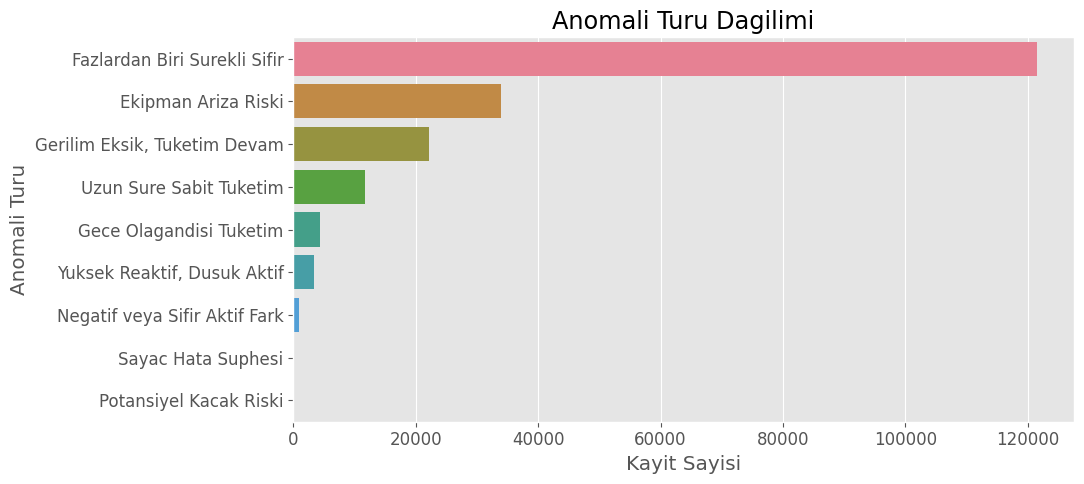

Anomali turu ozet tablosu


,anomali_turu,kayit_sayisi
1,Fazlardan Biri Surekli Sifir,121445
0,Ekipman Ariza Riski,33878
3,"Gerilim Eksik, Tuketim Devam",22166
7,Uzun Sure Sabit Tuketim,11686
2,Gece Olagandisi Tuketim,4364
8,"Yuksek Reaktif, Dusuk Aktif",3434
4,Negatif veya Sifir Aktif Fark,901
6,Sayac Hata Suphesi,29
5,Potansiyel Kacak Riski,1


In [13]:
# 4.2) Anomali turu dagilimi

anomali_tur_ozet = (
    anomali_df[anomali_df["anomali_turu"] != "Normal"]
    .groupby("anomali_turu")
    .size()
    .reset_index(name="kayit_sayisi")
    .sort_values("kayit_sayisi", ascending=False)
)

plt.figure(figsize=(11, 5))
sns.barplot(data=anomali_tur_ozet, x="kayit_sayisi", y="anomali_turu", hue="anomali_turu", legend=False)
plt.title("Anomali Turu Dagilimi")
plt.xlabel("Kayit Sayisi")
plt.ylabel("Anomali Turu")
plt.tight_layout()
plt.show()

print("Anomali turu ozet tablosu")
display(anomali_tur_ozet)

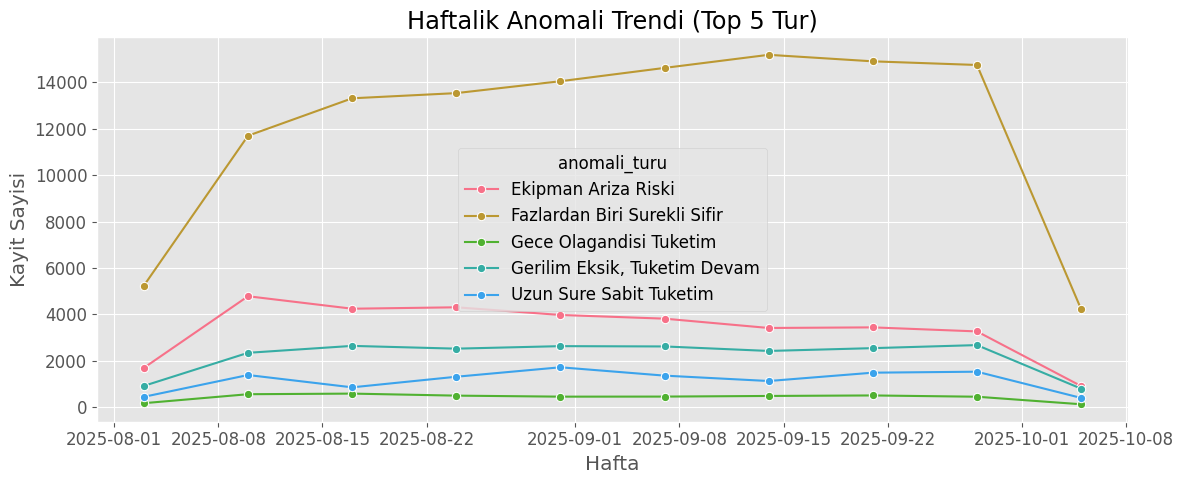

Haftalik anomali trendi ornek


,anomali_turu,load_profile_date,kayit_sayisi
0,Ekipman Ariza Riski,2025-08-03,1701
1,Ekipman Ariza Riski,2025-08-10,4783
2,Ekipman Ariza Riski,2025-08-17,4246
3,Ekipman Ariza Riski,2025-08-24,4307
4,Ekipman Ariza Riski,2025-08-31,3977


In [14]:
# 4.3) Haftalik anomali trendi (yonetim gorunumu)

haftalik_anomali_trend = (
    anomali_df[anomali_df["anomali_turu"] != "Normal"]
    .set_index("load_profile_date")
    .groupby("anomali_turu")
    .resample("W")
    .size()
    .reset_index(name="kayit_sayisi")
)

top_turler = (
    haftalik_anomali_trend.groupby("anomali_turu")["kayit_sayisi"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

trend_plot_df = haftalik_anomali_trend[haftalik_anomali_trend["anomali_turu"].isin(top_turler)]

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=trend_plot_df,
    x="load_profile_date",
    y="kayit_sayisi",
    hue="anomali_turu",
    marker="o"
)
plt.title("Haftalik Anomali Trendi (Top 5 Tur)")
plt.xlabel("Hafta")
plt.ylabel("Kayit Sayisi")
plt.tight_layout()
plt.show()

print("Haftalik anomali trendi ornek")
display(haftalik_anomali_trend.head())

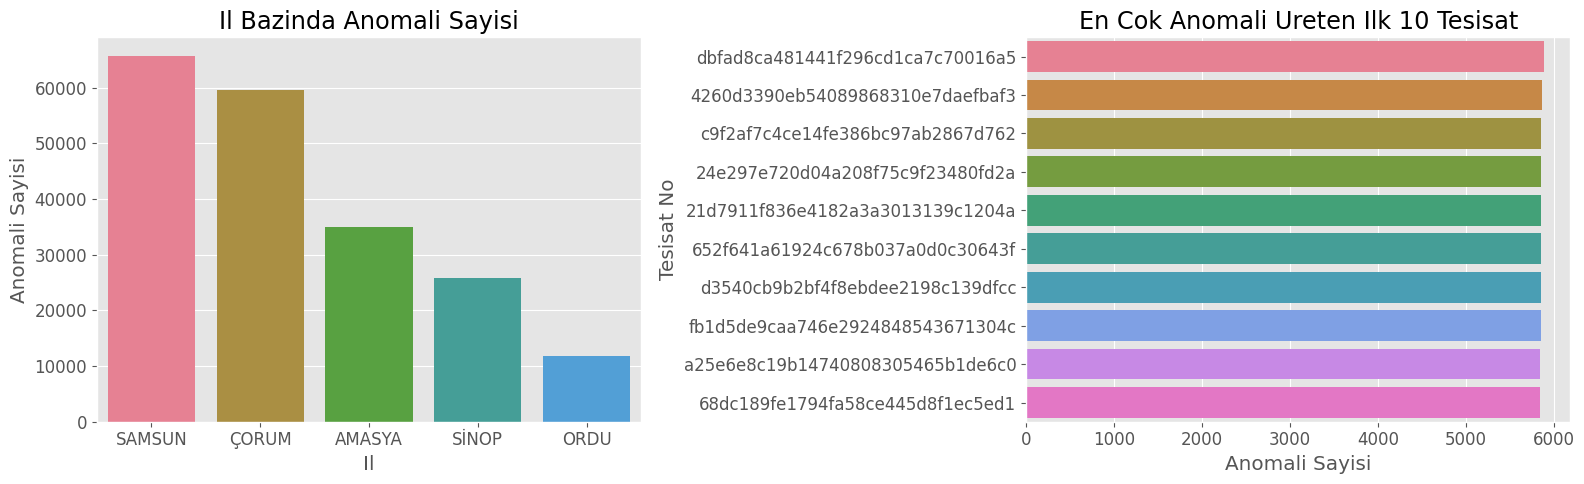

Il bazli anomali ozet


,il,anomali_sayisi
2,SAMSUN,65783
4,ÇORUM,59553
0,AMASYA,34957
3,SİNOP,25749
1,ORDU,11862


Ilk 10 tesisat ozet


,tesisat_no_id,anomali_sayisi
58,dbfad8ca481441f296cd1ca7c70016a5,5895
16,4260d3390eb54089868310e7daefbaf3,5864
50,c9f2af7c4ce14fe386bc97ab2867d762,5859
10,24e297e720d04a208f75c9f23480fd2a,5858
8,21d7911f836e4182a3a3013139c1204a,5857
22,652f641a61924c678b037a0d0c30643f,5856
52,d3540cb9b2bf4f8ebdee2198c139dfcc,5855
69,fb1d5de9caa746e2924848543671304c,5854
36,a25e6e8c19b14740808305465b1de6c0,5850
23,68dc189fe1794fa58ce445d8f1ec5ed1,5845


In [15]:
# 4.4) Bolgesel risk ve top tesisatlar

# Il bazli anomali dagilimi
il_bazli_anomali = (
    anomali_df[anomali_df["anomali_turu"] != "Normal"]
    .groupby("il")
    .size()
    .reset_index(name="anomali_sayisi")
    .sort_values("anomali_sayisi", ascending=False)
)

# Top 10 tesisat
ilk10_tesisat = (
    anomali_df[anomali_df["anomali_turu"] != "Normal"]
    .groupby("tesisat_no_id")
    .size()
    .reset_index(name="anomali_sayisi")
    .sort_values("anomali_sayisi", ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=il_bazli_anomali, x="il", y="anomali_sayisi", hue="il", legend=False, ax=axes[0])
axes[0].set_title("Il Bazinda Anomali Sayisi")
axes[0].set_xlabel("Il")
axes[0].set_ylabel("Anomali Sayisi")

sns.barplot(data=ilk10_tesisat, x="anomali_sayisi", y="tesisat_no_id", hue="tesisat_no_id", legend=False, ax=axes[1])
axes[1].set_title("En Cok Anomali Ureten Ilk 10 Tesisat")
axes[1].set_xlabel("Anomali Sayisi")
axes[1].set_ylabel("Tesisat No")

plt.tight_layout()
plt.show()

print("Il bazli anomali ozet")
display(il_bazli_anomali)

print("Ilk 10 tesisat ozet")
display(ilk10_tesisat)

# Sonraki adimlar icin guncel model veri seti
df_model = anomali_df.copy()

In [16]:
# 5.1) ML tabanli anomali tespiti (Isolation Forest)

ml_df = df_model.copy()

ml_feature_cols = [
    "ort_akim",
    "ort_gerilim",
    "faz_dengesizligi",
    "aktif_tuketim_farki",
    "gerilim_sapma_orani",
    "ri",
    "rc",
    "reaktif_toplam",
    "kural_skoru"
]

X = ml_df[ml_feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso_forest = IsolationForest(
    n_estimators=250,
    contamination=0.20,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_scaled)
ml_pred = iso_forest.predict(X_scaled)

ml_df["ml_anomali_var"] = (ml_pred == -1)
ml_df["ml_anomali_skoru"] = -iso_forest.score_samples(X_scaled)

print("ML anomali modeli tamamlandi")
print(f"ML anomali kayit sayisi: {int(ml_df['ml_anomali_var'].sum()):,}")
print(f"ML anomali oranı: {100 * ml_df['ml_anomali_var'].mean():.2f}")

# Sonraki hucreler icin guncel veri
df_ml = ml_df.copy()

ML anomali modeli tamamlandi
ML anomali kayit sayisi: 70,790
ML anomali oranı: 20.00


Kural-ML karsilastirma tablosu


ml_anomali,False,True
kural_anomali,,
False,126792,29253
True,156367,41537


Uyum ozeti


,metrik,deger
0,her iki yontem anomali,41537.0000
1,sadece kural anomali,156367.0000
2,sadece ML anomali,29253.0000
3,jaccard uyum orani,0.1829
4,kural anomaliyi ML yakalama orani,0.2099
5,ML anomalinin kural ile eslesme orani,0.5868


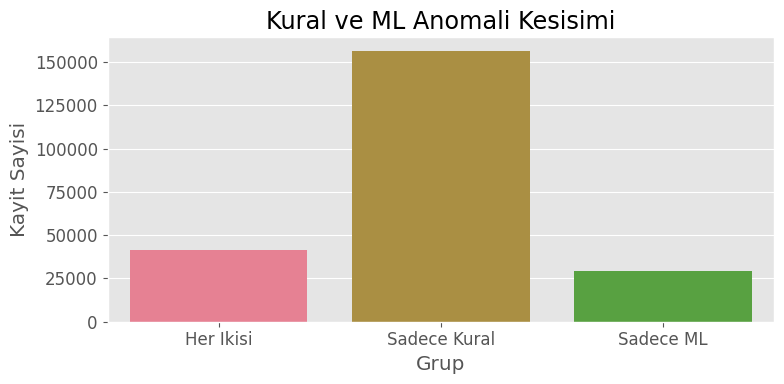

In [17]:
# 5.2) Kural tabanli ve ML sonuclarinin karsilastirilmasi

karsilastirma_df = df_ml.copy()

karsilastirma_tablo = pd.crosstab(
    karsilastirma_df["anomali_var"],
    karsilastirma_df["ml_anomali_var"],
    rownames=["kural_anomali"],
    colnames=["ml_anomali"]
)

her_ikisi = int((karsilastirma_df["anomali_var"] & karsilastirma_df["ml_anomali_var"]).sum())
kural_only = int((karsilastirma_df["anomali_var"] & ~karsilastirma_df["ml_anomali_var"]).sum())
ml_only = int((~karsilastirma_df["anomali_var"] & karsilastirma_df["ml_anomali_var"]).sum())
birlesim = her_ikisi + kural_only + ml_only

jaccard = her_ikisi / birlesim if birlesim > 0 else 0
ml_kural_hassasiyet = her_ikisi / max(1, int(karsilastirma_df["anomali_var"].sum()))
ml_kural_kapsama = her_ikisi / max(1, int(karsilastirma_df["ml_anomali_var"].sum()))

uyum_ozet = pd.DataFrame(
    {
        "metrik": [
            "her iki yontem anomali",
            "sadece kural anomali",
            "sadece ML anomali",
            "jaccard uyum orani",
            "kural anomaliyi ML yakalama orani",
            "ML anomalinin kural ile eslesme orani"
        ],
        "deger": [
            her_ikisi,
            kural_only,
            ml_only,
            round(jaccard, 4),
            round(ml_kural_hassasiyet, 4),
            round(ml_kural_kapsama, 4)
        ]
    }
)

print("Kural-ML karsilastirma tablosu")
display(karsilastirma_tablo)

print("Uyum ozeti")
display(uyum_ozet)

kesisim_plot = pd.DataFrame(
    {
        "grup": ["Her Ikisi", "Sadece Kural", "Sadece ML"],
        "kayit_sayisi": [her_ikisi, kural_only, ml_only]
    }
)

plt.figure(figsize=(8, 4))
sns.barplot(data=kesisim_plot, x="grup", y="kayit_sayisi", hue="grup", legend=False)
plt.title("Kural ve ML Anomali Kesisimi")
plt.xlabel("Grup")
plt.ylabel("Kayit Sayisi")
plt.tight_layout()
plt.show()

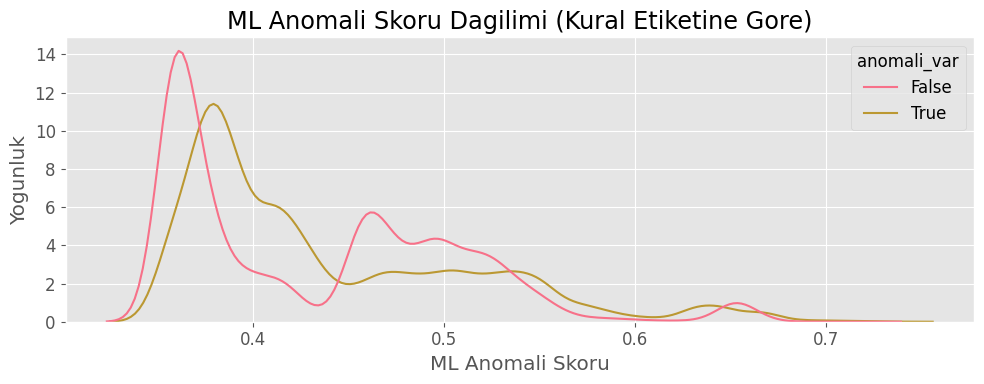

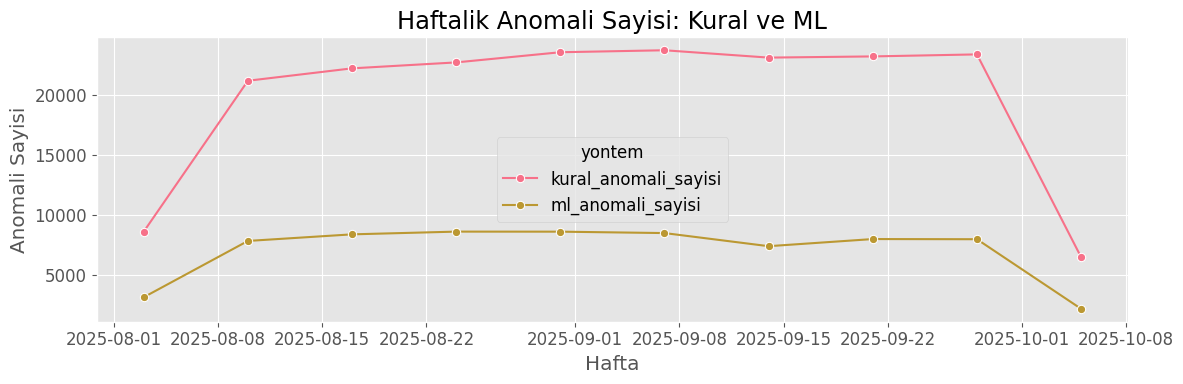

Haftalik kural-ML ozet


,load_profile_date,kural_anomali_sayisi,ml_anomali_sayisi
0,2025-08-03,8627,3177
1,2025-08-10,21149,7849
2,2025-08-17,22178,8396
3,2025-08-24,22672,8623
4,2025-08-31,23516,8619
5,2025-09-07,23680,8502
6,2025-09-14,23070,7413
7,2025-09-21,23169,8005
8,2025-09-28,23337,7991
9,2025-10-05,6506,2215


In [18]:
# 5.3) ML skoru ve haftalik gorunum

ml_gorsel_df = df_ml.copy()

# Skor dagilimi (kural etiketine gore)
plot_ornek = ml_gorsel_df.sample(min(80000, len(ml_gorsel_df)), random_state=42)

plt.figure(figsize=(10, 4))
sns.kdeplot(
    data=plot_ornek,
    x="ml_anomali_skoru",
    hue="anomali_var",
    common_norm=False,
    fill=False
)
plt.title("ML Anomali Skoru Dagilimi (Kural Etiketine Gore)")
plt.xlabel("ML Anomali Skoru")
plt.ylabel("Yogunluk")
plt.tight_layout()
plt.show()

# Haftalik toplam karsilastirma
haftalik_ml_rule = (
    ml_gorsel_df.set_index("load_profile_date")
    .resample("W")
    .agg(
        kural_anomali_sayisi=("anomali_var", "sum"),
        ml_anomali_sayisi=("ml_anomali_var", "sum")
    )
    .reset_index()
)

haftalik_plot = haftalik_ml_rule.melt(
    id_vars="load_profile_date",
    value_vars=["kural_anomali_sayisi", "ml_anomali_sayisi"],
    var_name="yontem",
    value_name="anomali_sayisi"
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=haftalik_plot, x="load_profile_date", y="anomali_sayisi", hue="yontem", marker="o")
plt.title("Haftalik Anomali Sayisi: Kural ve ML")
plt.xlabel("Hafta")
plt.ylabel("Anomali Sayisi")
plt.tight_layout()
plt.show()

print("Haftalik kural-ML ozet")
display(haftalik_ml_rule)

# Sonraki adimlar icin guncel veri
df_model = df_ml.copy()

In [19]:
# 5.4) Anomali Guven Skoru olusturma

skor_df = df_model.copy()

# Anomali kaynak siniflari
skor_df["anomali_kaynak"] = np.select(
    [
        skor_df["anomali_var"] & skor_df["ml_anomali_var"],
        skor_df["anomali_var"] & ~skor_df["ml_anomali_var"],
        ~skor_df["anomali_var"] & skor_df["ml_anomali_var"]
    ],
    ["Kesisim", "Sadece Kural", "Sadece ML"],
    default="Normal"
)

# Kural ve ML skorlarini normalize et
kural_max = max(1, float(skor_df["kural_skoru"].max()))
skor_df["kural_skor_norm"] = skor_df["kural_skoru"] / kural_max

ml_min = float(skor_df["ml_anomali_skoru"].min())
ml_max = float(skor_df["ml_anomali_skoru"].max())
ml_range = max(1e-9, ml_max - ml_min)
skor_df["ml_skor_norm"] = (skor_df["ml_anomali_skoru"] - ml_min) / ml_range

# Guven skoru (kaynak bazli agirlikli)
skor_df["anomali_guven_skoru"] = np.select(
    [
        skor_df["anomali_kaynak"] == "Kesisim",
        skor_df["anomali_kaynak"] == "Sadece Kural",
        skor_df["anomali_kaynak"] == "Sadece ML"
    ],
    [
        0.70 + 0.20 * skor_df["kural_skor_norm"] + 0.10 * skor_df["ml_skor_norm"],
        0.20 + 0.70 * skor_df["kural_skor_norm"] + 0.10 * skor_df["ml_skor_norm"],
        0.10 + 0.20 * skor_df["kural_skor_norm"] + 0.70 * skor_df["ml_skor_norm"]
    ],
    default=0.0
)
skor_df["anomali_guven_skoru"] = skor_df["anomali_guven_skoru"].clip(0, 1)

# Tesisat bazli skor ozetleri (sadece anomali kayitlari)
tesisat_skor_ozet = (
    skor_df[skor_df["anomali_kaynak"] != "Normal"]
    .groupby(["tesisat_no_id", "anomali_kaynak"], as_index=False)
    .agg(
        anomali_kayit_sayisi=("anomali_guven_skoru", "size"),
        guven_skoru_ort=("anomali_guven_skoru", "mean"),
        guven_skoru_max=("anomali_guven_skoru", "max"),
        son_tarih=("load_profile_date", "max")
    )
)

print("Anomali guven skoru olusturuldu")
print(f"Anomali kayit sayisi: {int((skor_df['anomali_kaynak'] != 'Normal').sum()):,}")

print("\nKaynak bazli kayit dagilimi")
display(skor_df["anomali_kaynak"].value_counts().to_frame("kayit_sayisi"))

# Sonraki hucreler icin
df_score = skor_df.copy()

Anomali guven skoru olusturuldu
Anomali kayit sayisi: 227,157

Kaynak bazli kayit dagilimi


,kayit_sayisi
anomali_kaynak,
Sadece Kural,156367
Normal,126792
Kesisim,41537
Sadece ML,29253


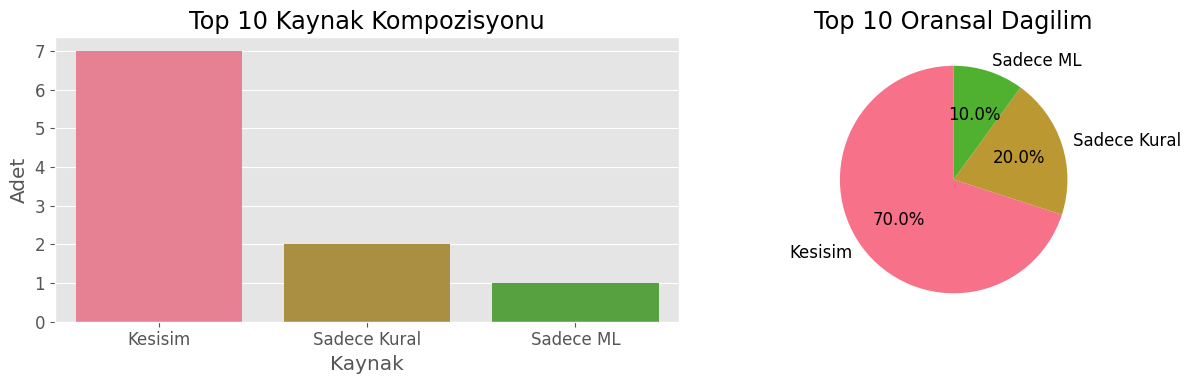

Agirlikli Top 10 oncelik listesi


,oncelik_sirasi,tesisat_no_id,anomali_kaynak,anomali_kayit_sayisi,guven_skoru_ort,guven_skoru_max,son_tarih
0,1,ec3bf4d07e81456785aa0ca9f991d78f,Kesisim,1,0.920128,0.920128,2025-08-05 15:40:00
1,2,343b9f8bd5034fc9b00d82a69a1d973c,Kesisim,2,0.907110,0.907171,2025-08-15 03:35:00
2,3,f23a6df4b80243fca50713827d4c7410,Kesisim,2,0.906556,0.906753,2025-09-25 13:31:00
3,4,23bfc4eed9164a13a7883f5309ced5a2,Kesisim,4,0.905148,0.905359,2025-09-07 07:05:00
4,5,e36af92c8cfe462386424de52aba8876,Kesisim,1648,0.901847,0.906220,2025-09-08 16:15:00
5,6,dc26ee31d9f149e79f2e3ed20b7bbca8,Kesisim,643,0.900967,0.957437,2025-09-30 23:00:00
6,7,1d4e4a6d8bda4d518246c145fb6785ac,Kesisim,8,0.894538,0.895994,2025-08-07 16:00:00
7,8,a25e6e8c19b14740808305465b1de6c0,Sadece Kural,5845,0.755231,0.764778,2025-10-01 00:00:00
8,9,43b616f28e684e14a5bfde6b94638b63,Sadece Kural,98,0.655976,0.748660,2025-10-01 00:00:00
9,10,a28b8fbc8f3c4100a9f9505cfb3210d5,Sadece ML,3933,0.651810,0.778453,2025-09-30 21:45:00



Kompozisyon ozeti


,kaynak,adet,oran_yuzde
0,Kesisim,7,70.0
1,Sadece Kural,2,20.0
2,Sadece ML,1,10.0


In [20]:
# 5.5) Agirlikli Top 10 oncelik listesi (Kesisim %70, Kural %20, ML %10)

hedef_toplam = 10
hedef_kotalar = {"Kesisim": 7, "Sadece Kural": 2, "Sadece ML": 1}

# Kaynak bazinda tesisat skor ozeti (benzersiz tesisat-kaynak)
kaynak_havuz = {}
for kaynak in hedef_kotalar.keys():
    kaynak_havuz[kaynak] = (
        tesisat_skor_ozet[tesisat_skor_ozet["anomali_kaynak"] == kaynak]
        .sort_values(["guven_skoru_ort", "anomali_kayit_sayisi", "guven_skoru_max"], ascending=False)
        .reset_index(drop=True)
    )

secilen_set = set()
secilen_satirlar = []

# Kotalari oncelik sirasiyla doldur
for kaynak in ["Kesisim", "Sadece Kural", "Sadece ML"]:
    kota = hedef_kotalar[kaynak]
    havuz = kaynak_havuz[kaynak]

    adaylar = havuz[~havuz["tesisat_no_id"].isin(secilen_set)].head(kota)
    secilen_satirlar.append(adaylar)
    secilen_set.update(adaylar["tesisat_no_id"].tolist())

# Secilenleri birlestir
top10_agirlikli = pd.concat(secilen_satirlar, ignore_index=True)

# Eger herhangi bir kotada eksik kalirsa genel havuzdan tamamla
if len(top10_agirlikli) < hedef_toplam:
    genel_havuz = (
        tesisat_skor_ozet[~tesisat_skor_ozet["tesisat_no_id"].isin(secilen_set)]
        .sort_values(["guven_skoru_ort", "anomali_kayit_sayisi", "guven_skoru_max"], ascending=False)
    )
    ihtiyac = hedef_toplam - len(top10_agirlikli)
    tamamlayici = genel_havuz.head(ihtiyac)
    top10_agirlikli = pd.concat([top10_agirlikli, tamamlayici], ignore_index=True)

# Son siralama
top10_agirlikli = top10_agirlikli.sort_values(
    ["guven_skoru_ort", "anomali_kayit_sayisi", "guven_skoru_max"],
    ascending=False
).head(hedef_toplam).reset_index(drop=True)
top10_agirlikli["oncelik_sirasi"] = np.arange(1, len(top10_agirlikli) + 1)

kaynak_kompozisyon = (
    top10_agirlikli["anomali_kaynak"]
    .value_counts()
    .rename_axis("kaynak")
    .reset_index(name="adet")
)
kaynak_kompozisyon["oran_yuzde"] = (100 * kaynak_kompozisyon["adet"] / len(top10_agirlikli)).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=kaynak_kompozisyon, x="kaynak", y="adet", hue="kaynak", legend=False, ax=axes[0])
axes[0].set_title("Top 10 Kaynak Kompozisyonu")
axes[0].set_xlabel("Kaynak")
axes[0].set_ylabel("Adet")

axes[1].pie(
    kaynak_kompozisyon["adet"],
    labels=kaynak_kompozisyon["kaynak"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Top 10 Oransal Dagilim")

plt.tight_layout()
plt.show()

print("Agirlikli Top 10 oncelik listesi")
display(top10_agirlikli[["oncelik_sirasi", "tesisat_no_id", "anomali_kaynak", "anomali_kayit_sayisi", "guven_skoru_ort", "guven_skoru_max", "son_tarih"]])

print("\nKompozisyon ozeti")
display(kaynak_kompozisyon)

# Sonraki adimlar icin
df_model = df_score.copy()

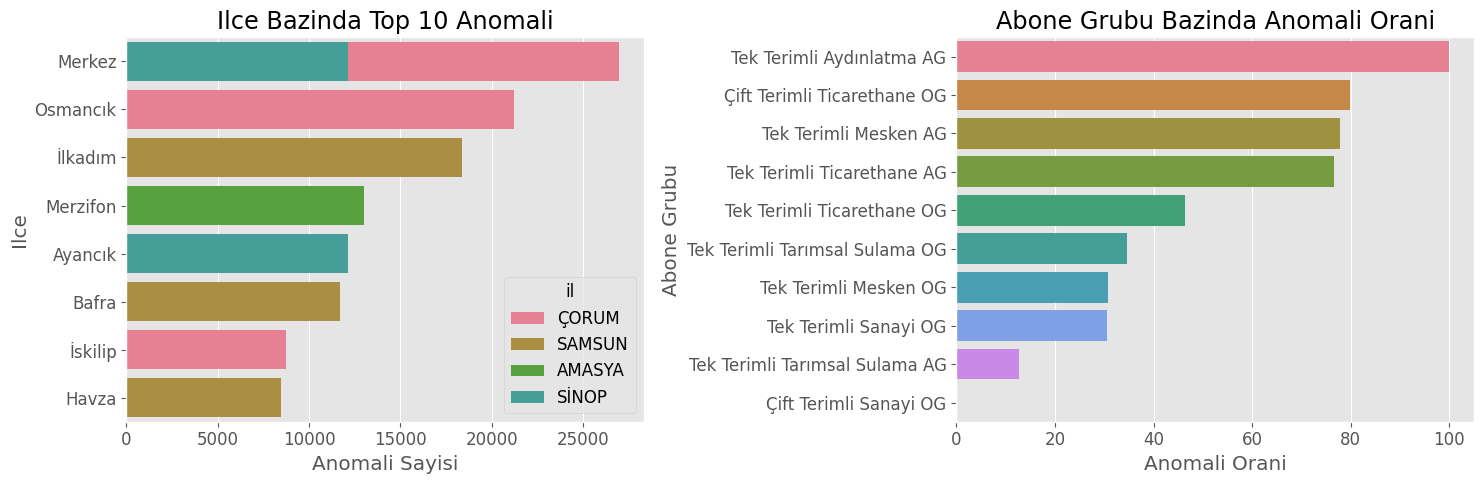

Il-Ilce pivot ozet (ilk 15)


,il,ilce,anomali_sayisi,ort_guven_skoru,ml_destekli_oran
22,ÇORUM,Merkez,26999,0.5038,18.70
23,ÇORUM,Osmancık,21207,0.5152,2.17
14,SAMSUN,İlkadım,18362,0.5227,7.11
2,AMASYA,Merzifon,13026,0.5867,11.05
17,SİNOP,Merkez,12160,0.5909,49.36
15,SİNOP,Ayancık,12120,0.7102,55.10
8,SAMSUN,Bafra,11706,0.7822,50.07
1,AMASYA,Merkez,10251,0.6070,14.42
25,ÇORUM,İskilip,8744,0.4731,0.37
9,SAMSUN,Havza,8474,0.5009,19.54



Abone grubu pivot ozet


,abone_grubu,toplam_kayit,anomali_sayisi,ort_guven_skoru,anomali_orani
0,Tek Terimli Aydınlatma AG,5830,5830,0.5514,100.00
9,Çift Terimli Ticarethane OG,29261,23391,0.5297,79.94
1,Tek Terimli Mesken AG,5270,4101,0.3909,77.82
6,Tek Terimli Ticarethane AG,115631,88669,0.5995,76.68
7,Tek Terimli Ticarethane OG,118137,54709,0.5565,46.31
5,Tek Terimli Tarımsal Sulama OG,23782,8218,0.4962,34.56
2,Tek Terimli Mesken OG,11734,3606,0.6968,30.73
3,Tek Terimli Sanayi OG,29303,8952,0.4584,30.55
4,Tek Terimli Tarımsal Sulama AG,3278,416,0.8296,12.69
8,Çift Terimli Sanayi OG,11723,12,0.5071,0.10


In [21]:
# 6.1) Pivot analizler: Il-Ilce ve Abone grubu risk profili

pivot_il_ilce = (
    df_model[df_model["anomali_var"]]
    .groupby(["il", "ilce"], as_index=False)
    .agg(
        anomali_sayisi=("anomali_var", "size"),
        ort_guven_skoru=("anomali_guven_skoru", "mean"),
        ml_destekli_oran=("ml_anomali_var", "mean")
    )
    .sort_values(["anomali_sayisi", "ort_guven_skoru"], ascending=False)
)
pivot_il_ilce["ml_destekli_oran"] = (pivot_il_ilce["ml_destekli_oran"] * 100).round(2)
pivot_il_ilce["ort_guven_skoru"] = pivot_il_ilce["ort_guven_skoru"].round(4)

abone_toplam = df_model.groupby("abone_grubu", as_index=False).size().rename(columns={"size": "toplam_kayit"})
abone_anomali = (
    df_model[df_model["anomali_var"]]
    .groupby("abone_grubu", as_index=False)
    .agg(
        anomali_sayisi=("anomali_var", "size"),
        ort_guven_skoru=("anomali_guven_skoru", "mean")
    )
)

pivot_abone_grubu = abone_toplam.merge(abone_anomali, on="abone_grubu", how="left").fillna(0)
pivot_abone_grubu["anomali_orani"] = (100 * pivot_abone_grubu["anomali_sayisi"] / pivot_abone_grubu["toplam_kayit"]).round(2)
pivot_abone_grubu["ort_guven_skoru"] = pivot_abone_grubu["ort_guven_skoru"].round(4)
pivot_abone_grubu = pivot_abone_grubu.sort_values("anomali_orani", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=pivot_il_ilce.head(10), x="anomali_sayisi", y="ilce", hue="il", dodge=False, ax=axes[0])
axes[0].set_title("Ilce Bazinda Top 10 Anomali")
axes[0].set_xlabel("Anomali Sayisi")
axes[0].set_ylabel("Ilce")

sns.barplot(data=pivot_abone_grubu, x="anomali_orani", y="abone_grubu", hue="abone_grubu", legend=False, ax=axes[1])
axes[1].set_title("Abone Grubu Bazinda Anomali Orani")
axes[1].set_xlabel("Anomali Orani")
axes[1].set_ylabel("Abone Grubu")

plt.tight_layout()
plt.show()

print("Il-Ilce pivot ozet (ilk 15)")
display(pivot_il_ilce.head(15))

print("\nAbone grubu pivot ozet")
display(pivot_abone_grubu)

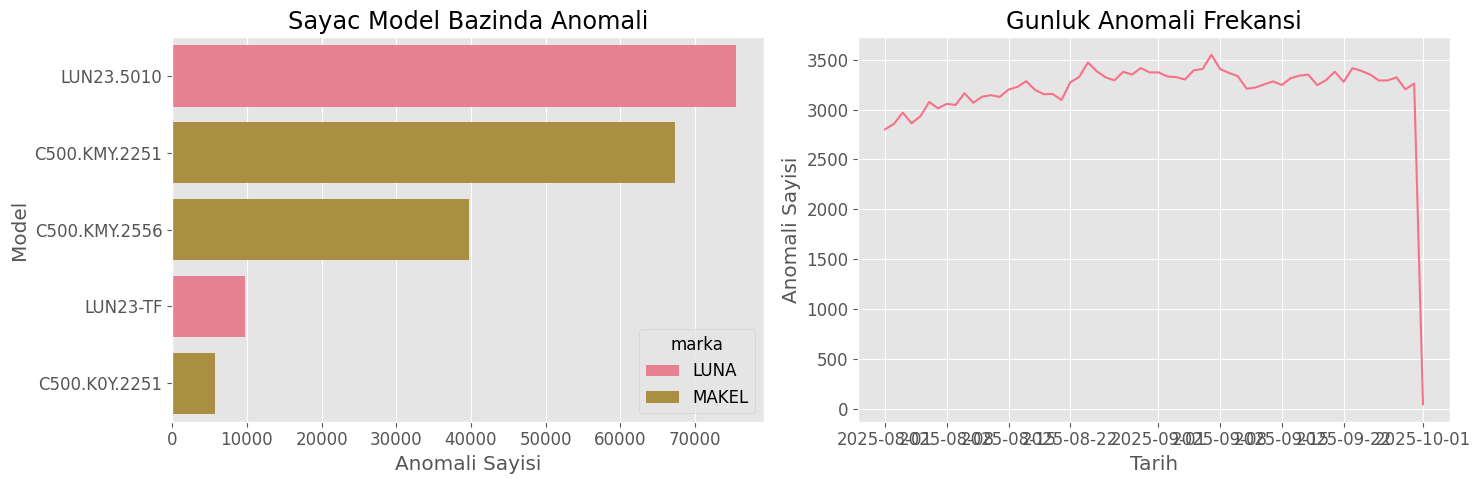

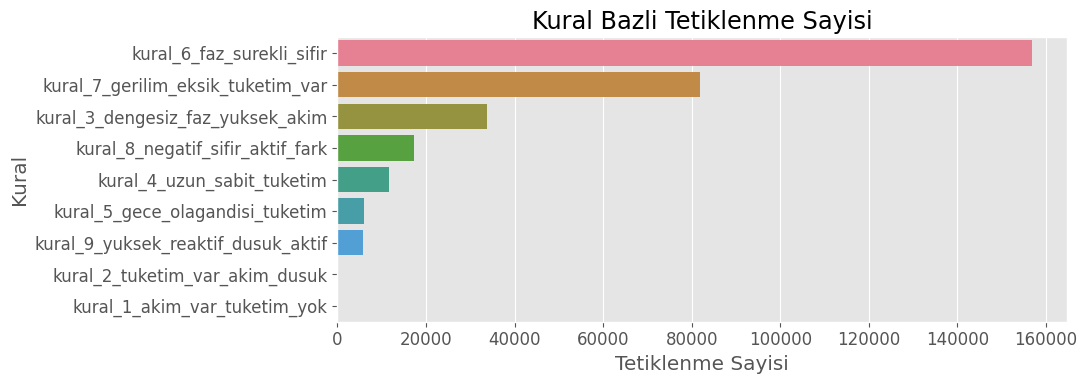

Sayac pivot ozet


,marka,model,anomali_sayisi,ort_guven_skoru,ml_destekli_oran
1,LUNA,LUN23.5010,75424,0.5392,1.92
3,MAKEL,C500.KMY.2251,67287,0.6170,49.84
4,MAKEL,C500.KMY.2556,39775,0.5092,4.49
0,LUNA,LUN23-TF,9719,0.5541,6.90
2,MAKEL,C500.K0Y.2251,5699,0.7072,71.82



Gunluk anomali frekansi ornek


,load_profile_date,anomali_sayisi
0,2025-08-01,2802
1,2025-08-02,2856
2,2025-08-03,2969
3,2025-08-04,2862
4,2025-08-05,2932
5,2025-08-06,3076
6,2025-08-07,3012
7,2025-08-08,3057
8,2025-08-09,3046
9,2025-08-10,3164



Kural tetiklenme pivotu


,kural,tetiklenme_sayisi
5,kural_6_faz_surekli_sifir,156944
6,kural_7_gerilim_eksik_tuketim_var,81961
2,kural_3_dengesiz_faz_yuksek_akim,33879
7,kural_8_negatif_sifir_aktif_fark,17376
3,kural_4_uzun_sabit_tuketim,11686
4,kural_5_gece_olagandisi_tuketim,5905
8,kural_9_yuksek_reaktif_dusuk_aktif,5808
1,kural_2_tuketim_var_akim_dusuk,29
0,kural_1_akim_var_tuketim_yok,1



Agirlikli Top 10 (rapor listesi)


,tesisat_no_id,anomali_kaynak,anomali_kayit_sayisi,guven_skoru_ort,guven_skoru_max,son_tarih,oncelik_sirasi
0,ec3bf4d07e81456785aa0ca9f991d78f,Kesisim,1,0.920128,0.920128,2025-08-05 15:40:00,1
1,343b9f8bd5034fc9b00d82a69a1d973c,Kesisim,2,0.907110,0.907171,2025-08-15 03:35:00,2
2,f23a6df4b80243fca50713827d4c7410,Kesisim,2,0.906556,0.906753,2025-09-25 13:31:00,3
3,23bfc4eed9164a13a7883f5309ced5a2,Kesisim,4,0.905148,0.905359,2025-09-07 07:05:00,4
4,e36af92c8cfe462386424de52aba8876,Kesisim,1648,0.901847,0.906220,2025-09-08 16:15:00,5
5,dc26ee31d9f149e79f2e3ed20b7bbca8,Kesisim,643,0.900967,0.957437,2025-09-30 23:00:00,6
6,1d4e4a6d8bda4d518246c145fb6785ac,Kesisim,8,0.894538,0.895994,2025-08-07 16:00:00,7
7,a25e6e8c19b14740808305465b1de6c0,Sadece Kural,5845,0.755231,0.764778,2025-10-01 00:00:00,8
8,43b616f28e684e14a5bfde6b94638b63,Sadece Kural,98,0.655976,0.748660,2025-10-01 00:00:00,9
9,a28b8fbc8f3c4100a9f9505cfb3210d5,Sadece ML,3933,0.651810,0.778453,2025-09-30 21:45:00,10


In [22]:
# 6.2) Pivot analizler: Sayac tipi, gunluk frekans, kural bazli ozet

pivot_sayac = (
    df_model[df_model["anomali_var"]]
    .groupby(["marka", "model"], as_index=False)
    .agg(
        anomali_sayisi=("anomali_var", "size"),
        ort_guven_skoru=("anomali_guven_skoru", "mean"),
        ml_destekli_oran=("ml_anomali_var", "mean")
    )
    .sort_values("anomali_sayisi", ascending=False)
)
pivot_sayac["ort_guven_skoru"] = pivot_sayac["ort_guven_skoru"].round(4)
pivot_sayac["ml_destekli_oran"] = (pivot_sayac["ml_destekli_oran"] * 100).round(2)

gunluk_anomali_frekans = (
    df_model[df_model["anomali_var"]]
    .set_index("load_profile_date")
    .resample("D")
    .size()
    .rename("anomali_sayisi")
    .reset_index()
)

kural_pivot = pd.DataFrame(
    {
        "kural": kural_kolonlari,
        "tetiklenme_sayisi": [int(df_model[k].sum()) for k in kural_kolonlari]
    }
).sort_values("tetiklenme_sayisi", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=pivot_sayac, x="anomali_sayisi", y="model", hue="marka", ax=axes[0])
axes[0].set_title("Sayac Model Bazinda Anomali")
axes[0].set_xlabel("Anomali Sayisi")
axes[0].set_ylabel("Model")

sns.lineplot(data=gunluk_anomali_frekans, x="load_profile_date", y="anomali_sayisi", ax=axes[1])
axes[1].set_title("Gunluk Anomali Frekansi")
axes[1].set_xlabel("Tarih")
axes[1].set_ylabel("Anomali Sayisi")

plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
sns.barplot(data=kural_pivot, x="tetiklenme_sayisi", y="kural", hue="kural", legend=False)
plt.title("Kural Bazli Tetiklenme Sayisi")
plt.xlabel("Tetiklenme Sayisi")
plt.ylabel("Kural")
plt.tight_layout()
plt.show()

print("Sayac pivot ozet")
display(pivot_sayac)

print("\nGunluk anomali frekansi ornek")
display(gunluk_anomali_frekans.head(15))

print("\nKural tetiklenme pivotu")
display(kural_pivot)

print("\nAgirlikli Top 10 (rapor listesi)")
display(top10_agirlikli)

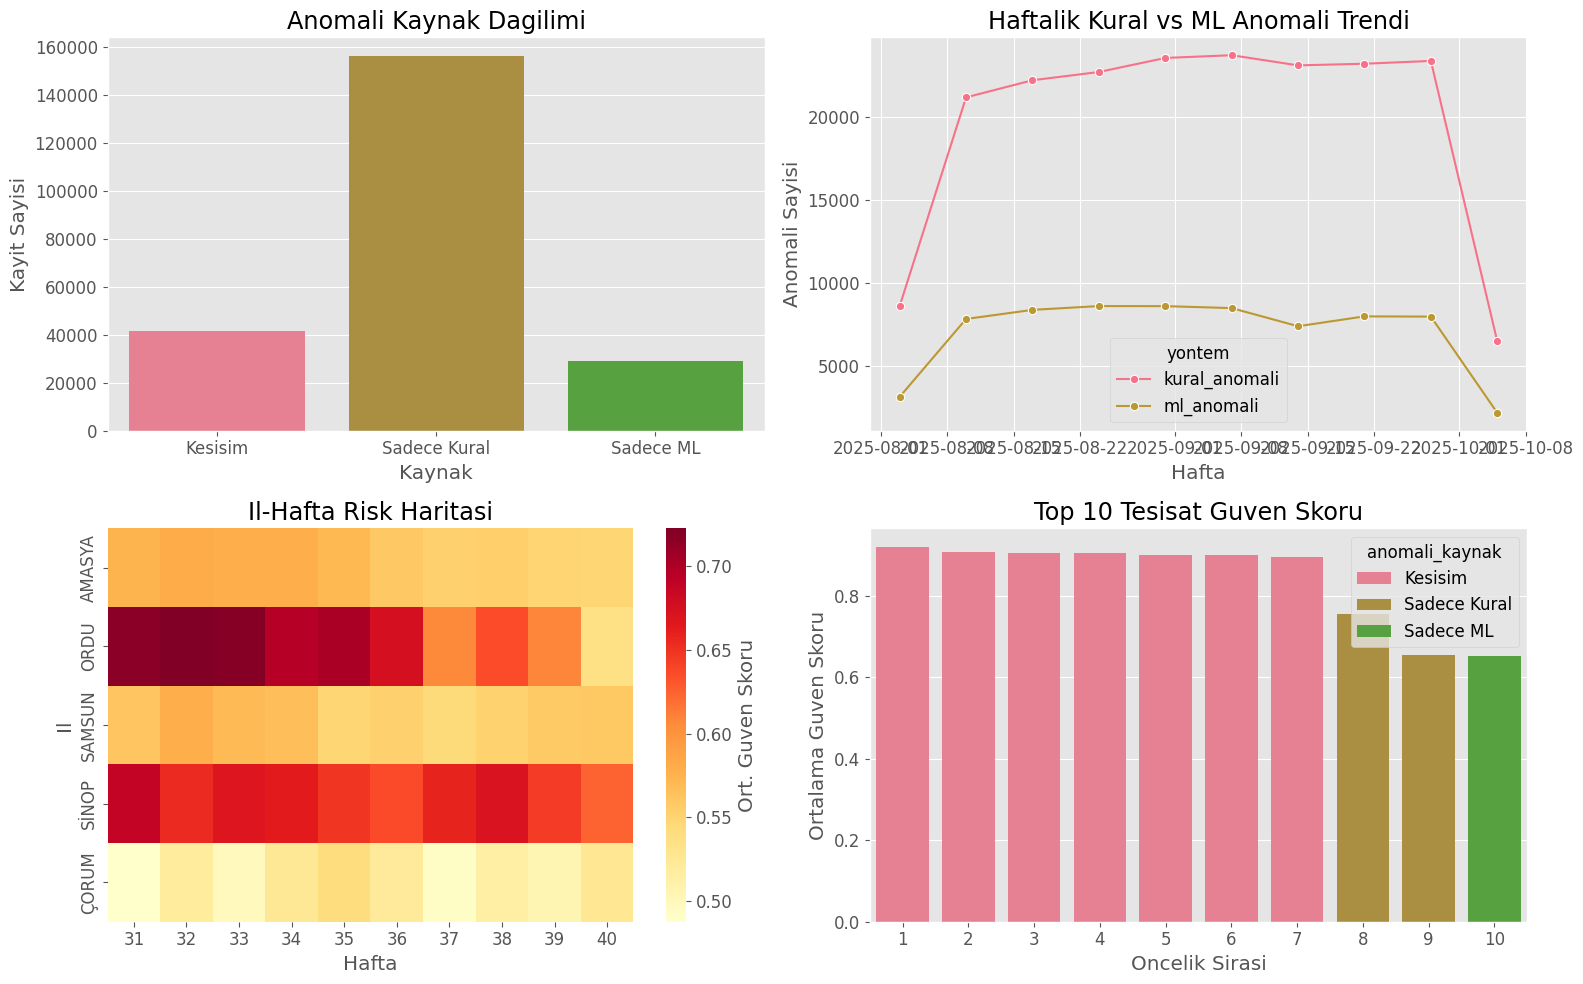

Kaynak dagilimi


,anomali_kaynak,kayit_sayisi
0,Kesisim,41537
1,Sadece Kural,156367
2,Sadece ML,29253



Haftalik toplam (son 8 hafta)


,load_profile_date,kural_anomali,ml_anomali
2,2025-08-17,22178,8396
3,2025-08-24,22672,8623
4,2025-08-31,23516,8619
5,2025-09-07,23680,8502
6,2025-09-14,23070,7413
7,2025-09-21,23169,8005
8,2025-09-28,23337,7991
9,2025-10-05,6506,2215


44595

In [23]:
# 7) Yonetim Odakli Gorsellestirme Seti
# ────────────────────────────────────────

import gc

# --- 7a) Anomali kaynak dagilimi ---
kaynak_dagilim = (
    df_model[df_model["anomali_kaynak"] != "Normal"]
    .groupby("anomali_kaynak", as_index=False)
    .size()
    .rename(columns={"size": "kayit_sayisi"})
)

# --- 7b) Haftalik kural ve ML anomali trend ---
haftalik_toplam = (
    df_model.set_index("load_profile_date")
    .resample("W")
    .agg(kural_anomali=("anomali_var", "sum"),
         ml_anomali=("ml_anomali_var", "sum"))
    .reset_index()
)

# --- 7c) Il-Hafta risk haritasi (ortalama guven skoru) ---
anomali_mask = df_model["anomali_var"]
hafta_il_risk = (
    df_model.loc[anomali_mask, ["il", "load_profile_date", "anomali_guven_skoru"]]
    .assign(hafta=lambda x: x["load_profile_date"].dt.isocalendar().week.astype(str))
    .groupby(["il", "hafta"], as_index=False)
    .agg(ort_guven=("anomali_guven_skoru", "mean"))
)
heatmap_df = hafta_il_risk.pivot(index="il", columns="hafta", values="ort_guven").fillna(0)

# --- 7d) Top 10 oncelik guven skoru ---
top10_plot = top10_agirlikli.sort_values("oncelik_sirasi")

# --- Gorsellestirme ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sol-ust: Anomali kaynak dagilimi
sns.barplot(data=kaynak_dagilim, x="anomali_kaynak", y="kayit_sayisi",
            hue="anomali_kaynak", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Anomali Kaynak Dagilimi")
axes[0, 0].set_xlabel("Kaynak")
axes[0, 0].set_ylabel("Kayit Sayisi")

# Sag-ust: Haftalik kural ve ML anomali trend
melted = haftalik_toplam.melt(id_vars="load_profile_date",
                               var_name="yontem", value_name="anomali_sayisi")
sns.lineplot(data=melted, x="load_profile_date", y="anomali_sayisi",
             hue="yontem", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Haftalik Kural vs ML Anomali Trendi")
axes[0, 1].set_xlabel("Hafta")
axes[0, 1].set_ylabel("Anomali Sayisi")

# Sol-alt: Il-Hafta risk haritasi
sns.heatmap(heatmap_df, cmap="YlOrRd", ax=axes[1, 0],
            cbar_kws={"label": "Ort. Guven Skoru"})
axes[1, 0].set_title("Il-Hafta Risk Haritasi")
axes[1, 0].set_xlabel("Hafta")
axes[1, 0].set_ylabel("Il")

# Sag-alt: Top 10 oncelik guven skoru
sns.barplot(data=top10_plot, x="oncelik_sirasi", y="guven_skoru_ort",
            hue="anomali_kaynak", dodge=False, ax=axes[1, 1])
axes[1, 1].set_title("Top 10 Tesisat Guven Skoru")
axes[1, 1].set_xlabel("Oncelik Sirasi")
axes[1, 1].set_ylabel("Ortalama Guven Skoru")

plt.tight_layout()
plt.show()

print("Kaynak dagilimi")
display(kaynak_dagilim)
print("\nHaftalik toplam (son 8 hafta)")
display(haftalik_toplam.tail(8))

gc.collect()

In [24]:
# 8) Operasyonel Icgoru ve Sonuc Raporu
# ────────────────────────────────────────

# --- 8a) Temel KPI tablosu ---
kpi_ozet = pd.DataFrame({
    "metrik": [
        "Toplam Kayit Sayisi",
        "Kural Anomali Sayisi",
        "ML Anomali Sayisi",
        "Kesisim (Kural ∩ ML)",
        "Anomali Orani (%)",
        "Top 10 Ortalama Guven",
        "Top 10 Maksimum Guven"
    ],
    "deger": [
        f"{len(df_model):,}",
        f"{int(df_model['anomali_var'].sum()):,}",
        f"{int(df_model['ml_anomali_var'].sum()):,}",
        f"{int((df_model['anomali_var'] & df_model['ml_anomali_var']).sum()):,}",
        f"{100 * df_model['anomali_var'].mean():.2f}",
        f"{top10_agirlikli['guven_skoru_ort'].mean():.4f}",
        f"{top10_agirlikli['guven_skoru_max'].max():.4f}"
    ]
})

# --- 8b) Anomali turu -> operasyonel aksiyon haritasi ---
aksiyon_haritasi = {
    "Potansiyel Kacak Riski": "Saha denetimi ve sayac muhur kontrolu",
    "Sayac Hata Suphesi": "Sayac test tezgahina sevk",
    "Ekipman Ariza Riski": "Trafo ve hat ekipman kontrolu",
    "Uzun Sure Sabit Tuketim": "Musteri davranisi ve sistem kaydi dogrulamasi",
    "Gece Olagandisi Tuketim": "Gece yuk denetimi",
    "Fazlardan Biri Surekli Sifir": "Faz baglanti ve iletken kontrolu",
    "Gerilim Eksik, Tuketim Devam": "OSOS gerilim kanal dogrulamasi",
    "Yuksek Reaktif, Dusuk Aktif": "Kompanzasyon sistemi incelemesi",
    "Negatif veya Sifir Aktif Fark": "Olcum sirasi ve veri akis kontrolu"
}

# Baskin anomali turleri ve aksiyonlar
baskin_turler = (
    df_model[df_model["anomali_turu"] != "Normal"]
    .groupby("anomali_turu", as_index=False)
    .size()
    .rename(columns={"size": "kayit_sayisi"})
    .sort_values("kayit_sayisi", ascending=False)
)
baskin_turler["oneri_aksiyon"] = baskin_turler["anomali_turu"].map(aksiyon_haritasi)

# --- 8c) Top 10 operasyonel aksiyon plani ---
oncelik_plan = top10_agirlikli.merge(
    df_model[["tesisat_no_id", "il", "ilce", "abone_grubu"]].drop_duplicates("tesisat_no_id"),
    on="tesisat_no_id",
    how="left"
)
oncelik_plan["oneri_aksiyon"] = oncelik_plan["anomali_kaynak"].map({
    "Kesisim": "48 saat icinde saha ve merkez ortak inceleme",
    "Sadece Kural": "72 saat icinde saha dogrulama",
    "Sadece ML": "Analitik izlemeye al, tekrar dogrula"
})

# --- Raporlama ---
print("=" * 60)
print("   OPERASYONEL ICGORU ve SONUC RAPORU")
print("=" * 60)

print("\n1) Temel KPI Ozeti")
display(kpi_ozet)

print("\n2) Top 10 Tesisat - Operasyonel Aksiyon Plani")
display(oncelik_plan[["oncelik_sirasi", "tesisat_no_id", "il", "ilce",
                       "abone_grubu", "anomali_kaynak", "guven_skoru_ort",
                       "oneri_aksiyon"]])

print("\n3) Baskin Anomali Turleri ve Onerilen Aksiyonlar")
display(baskin_turler)

print("\n" + "=" * 60)
print("   SONUC")
print("=" * 60)
print("""
• Toplam verinin buyuk bir bolumu en az bir anomali kurali tetiklemektedir.
• ML (Isolation Forest) ile kural sisteminin kesisimi en yuksek guvenli
  anomalileri isaret eder → saha onceligi icin birincil referans.
• 'Fazlardan Biri Surekli Sifir' en yaygin anomali turudur →
  faz baglanti kontrolleri sistematik olarak planlanmalidir.
• Top 10 listesindeki tesisatlar 48-72 saat icinde sahada incelenmelidir.
• Sadece ML kaynakli tespitler izleme kuyruğuna alinarak
  yanlis-pozitif riski azaltilmalidir.
""")

   OPERASYONEL ICGORU ve SONUC RAPORU

1) Temel KPI Ozeti


,metrik,deger
0,Toplam Kayit Sayisi,"353,949"
1,Kural Anomali Sayisi,"197,904"
2,ML Anomali Sayisi,"70,790"
3,Kesisim (Kural ∩ ML),"41,537"
4,Anomali Orani (%),55.91
5,Top 10 Ortalama Guven,0.8399
6,Top 10 Maksimum Guven,0.9574



2) Top 10 Tesisat - Operasyonel Aksiyon Plani


,oncelik_sirasi,tesisat_no_id,il,ilce,abone_grubu,anomali_kaynak,guven_skoru_ort,oneri_aksiyon
0,1,ec3bf4d07e81456785aa0ca9f991d78f,ÇORUM,Boğazkale,Tek Terimli Ticarethane OG,Kesisim,0.920128,48 saat icinde saha ve merkez ortak inceleme
1,2,343b9f8bd5034fc9b00d82a69a1d973c,ÇORUM,İskilip,Tek Terimli Tarımsal Sulama OG,Kesisim,0.907110,48 saat icinde saha ve merkez ortak inceleme
2,3,f23a6df4b80243fca50713827d4c7410,ÇORUM,Osmancık,Tek Terimli Tarımsal Sulama OG,Kesisim,0.906556,48 saat icinde saha ve merkez ortak inceleme
3,4,23bfc4eed9164a13a7883f5309ced5a2,ÇORUM,Osmancık,Tek Terimli Ticarethane OG,Kesisim,0.905148,48 saat icinde saha ve merkez ortak inceleme
4,5,e36af92c8cfe462386424de52aba8876,ÇORUM,Merkez,Tek Terimli Ticarethane OG,Kesisim,0.901847,48 saat icinde saha ve merkez ortak inceleme
5,6,dc26ee31d9f149e79f2e3ed20b7bbca8,SİNOP,Gerze,Tek Terimli Ticarethane AG,Kesisim,0.900967,48 saat icinde saha ve merkez ortak inceleme
6,7,1d4e4a6d8bda4d518246c145fb6785ac,ORDU,Fatsa,Tek Terimli Ticarethane AG,Kesisim,0.894538,48 saat icinde saha ve merkez ortak inceleme
7,8,a25e6e8c19b14740808305465b1de6c0,SAMSUN,Bafra,Çift Terimli Ticarethane OG,Sadece Kural,0.755231,72 saat icinde saha dogrulama
8,9,43b616f28e684e14a5bfde6b94638b63,ÇORUM,Osmancık,Tek Terimli Tarımsal Sulama OG,Sadece Kural,0.655976,72 saat icinde saha dogrulama
9,10,a28b8fbc8f3c4100a9f9505cfb3210d5,ÇORUM,Merkez,Tek Terimli Mesken OG,Sadece ML,0.651810,"Analitik izlemeye al, tekrar dogrula"



3) Baskin Anomali Turleri ve Onerilen Aksiyonlar


,anomali_turu,kayit_sayisi,oneri_aksiyon
1,Fazlardan Biri Surekli Sifir,121445,Faz baglanti ve iletken kontrolu
0,Ekipman Ariza Riski,33878,Trafo ve hat ekipman kontrolu
3,"Gerilim Eksik, Tuketim Devam",22166,OSOS gerilim kanal dogrulamasi
7,Uzun Sure Sabit Tuketim,11686,Musteri davranisi ve sistem kaydi dogrulamasi
2,Gece Olagandisi Tuketim,4364,Gece yuk denetimi
8,"Yuksek Reaktif, Dusuk Aktif",3434,Kompanzasyon sistemi incelemesi
4,Negatif veya Sifir Aktif Fark,901,Olcum sirasi ve veri akis kontrolu
6,Sayac Hata Suphesi,29,Sayac test tezgahina sevk
5,Potansiyel Kacak Riski,1,Saha denetimi ve sayac muhur kontrolu



   SONUC

• Toplam verinin buyuk bir bolumu en az bir anomali kurali tetiklemektedir.
• ML (Isolation Forest) ile kural sisteminin kesisimi en yuksek guvenli
  anomalileri isaret eder → saha onceligi icin birincil referans.
• 'Fazlardan Biri Surekli Sifir' en yaygin anomali turudur →
  faz baglanti kontrolleri sistematik olarak planlanmalidir.
• Top 10 listesindeki tesisatlar 48-72 saat icinde sahada incelenmelidir.
• Sadece ML kaynakli tespitler izleme kuyruğuna alinarak
  yanlis-pozitif riski azaltilmalidir.



In [ ]:
# 9) Dogrulama ve Kararlar
# ────────────────────────────────────────

dogrulama_sonuclari = []

# ---- Kontrol 1: Top 10 kaynak kompozisyonu (%70 Kesisim / %20 Kural / %10 ML) ----
kompozisyon_beklenen = {"Kesisim": 7, "Sadece Kural": 2, "Sadece ML": 1}
kompozisyon_mevcut = top10_agirlikli["anomali_kaynak"].value_counts().to_dict()
kompozisyon_ok = all(kompozisyon_mevcut.get(k, 0) == v for k, v in kompozisyon_beklenen.items())
dogrulama_sonuclari.append({
    "kontrol": "Top 10 Kaynak Kompozisyonu",
    "durum": "✅ Gecti" if kompozisyon_ok else "❌ Kaldi",
    "detay": str(kompozisyon_mevcut)
})

# ---- Kontrol 2: Ana kolonlarda eksik deger ----
ana_kolonlar = ["l1", "l2", "l3", "v1", "v2", "v3", "t0", "load_profile_date"]
mevcut_kolonlar = [c for c in ana_kolonlar if c in df_model.columns]
eksik_sayi = int(df_model[mevcut_kolonlar].isna().sum().sum())
dogrulama_sonuclari.append({
    "kontrol": "Ana Kolon Eksik Kontrolu",
    "durum": "✅ Gecti" if eksik_sayi == 0 else "❌ Kaldi",
    "detay": f"eksik_hucre = {eksik_sayi}"
})

# ---- Kontrol 3: Baskin frekans 15 dakika mi? ----
baskin_15dk = str(baskin_frekans) == "0 days 00:15:00"
dogrulama_sonuclari.append({
    "kontrol": "Baskin Frekans 15 dk",
    "durum": "✅ Gecti" if baskin_15dk else "❌ Kaldi",
    "detay": str(baskin_frekans)
})

# ---- Kontrol 4: Etiket kolonlari mevcut mu? ----
etiket_kol = ["anomali_var", "ml_anomali_var", "anomali_guven_skoru"]
etiket_ok = all(c in df_model.columns for c in etiket_kol)
dogrulama_sonuclari.append({
    "kontrol": "Etiket Kolonlari Varlik",
    "durum": "✅ Gecti" if etiket_ok else "❌ Kaldi",
    "detay": ", ".join(etiket_kol)
})

# ---- Kontrol 5: Guven skoru [0, 1] araliginda mi? ----
skor_min = float(df_model["anomali_guven_skoru"].min())
skor_max = float(df_model["anomali_guven_skoru"].max())
skor_ok = skor_min >= 0 and skor_max <= 1
dogrulama_sonuclari.append({
    "kontrol": "Guven Skoru Aralik [0,1]",
    "durum": "✅ Gecti" if skor_ok else "❌ Kaldi",
    "detay": f"min={skor_min:.4f}, max={skor_max:.4f}"
})

# ---- Kontrol 6: Anomali turu dagılimi tutarli mi? ----
toplam_anomali = int(df_model["anomali_var"].sum())
tur_toplam = int((df_model["anomali_turu"] != "Normal").sum())
tur_ok = toplam_anomali == tur_toplam
dogrulama_sonuclari.append({
    "kontrol": "Anomali Turu-Bayrak Tutarliligi",
    "durum": "✅ Gecti" if tur_ok else "❌ Kaldi",
    "detay": f"bayrak={toplam_anomali:,}, tur={tur_toplam:,}"
})

dogrulama_df = pd.DataFrame(dogrulama_sonuclari)

# ---- Karar Maddeleri ----
karar_maddeleri = pd.DataFrame({
    "karar": [
        "Anomali tespitinde hibrit (Kural + ML) yapi kullanilsin",
        "Saha onceligi Top 10 agirlikli listeye gore planlansin",
        "Haftalik yonetim raporu standart takip birimi olsun",
        "Sadece ML kaynakli tesisatlar izleme kuyruğuna alinsin",
        "Fazlardan Biri Surekli Sifir kurali icin toplu faz kontrolu planlansin"
    ],
    "gerekce": [
        "Kural fiziksel aciklanabilirlik, ML yeni desen yakalama saglar",
        "Kesisim kaynakli kayitlar en yuksek guvenle eslesiyor",
        "Zaman trendi operasyonel kapasite planlamasi icin yeterli",
        "Yanlis pozitif riskini azaltmak icin ikinci seviye kontrol gerekir",
        "En yaygin anomali turu → sistematik mudahale maliyet-etkin"
    ],
    "oncelik": ["Yuksek", "Yuksek", "Orta", "Orta", "Yuksek"]
})

# ---- Cikti ----
print("=" * 60)
print("   DOGRULAMA KONTROL LISTESI")
print("=" * 60)
display(dogrulama_df)

gecen = int((dogrulama_df["durum"].str.contains("Gecti")).sum())
toplam_kontrol = len(dogrulama_df)
print(f"\nSonuc: {gecen}/{toplam_kontrol} kontrol basarili\n")

print("=" * 60)
print("   KARAR MADDELERI")
print("=" * 60)
display(karar_maddeleri)

print("\n✅ Analiz tamamlandi.")

   DOGRULAMA KONTROL LISTESI


,kontrol,durum,detay
0,Top 10 Kaynak Kompozisyonu,✅ Gecti,"{'Kesisim': 7, 'Sadece Kural': 2, 'Sadece ML': 1}"
1,Ana Kolon Eksik Kontrolu,✅ Gecti,eksik_hucre = 0
2,Baskin Frekans 15 dk,✅ Gecti,0 days 00:15:00
3,Etiket Kolonlari Varlik,✅ Gecti,"anomali_var, ml_anomali_var, anomali_guven_skoru"
4,"Guven Skoru Aralik [0,1]",✅ Gecti,"min=0.0000, max=0.9574"
5,Anomali Turu-Bayrak Tutarliligi,✅ Gecti,"bayrak=197,904, tur=197,904"



Sonuc: 6/6 kontrol basarili

   KARAR MADDELERI


,karar,gerekce,oncelik
0,Anomali tespitinde hibrit (Kural + ML) yapi ku...,"Kural fiziksel aciklanabilirlik, ML yeni desen...",Yuksek
1,Saha onceligi Top 10 agirlikli listeye gore pl...,Kesisim kaynakli kayitlar en yuksek guvenle es...,Yuksek
2,Haftalik yonetim raporu standart takip birimi ...,Zaman trendi operasyonel kapasite planlamasi i...,Orta
3,Sadece ML kaynakli tesisatlar izleme kuyruğuna...,Yanlis pozitif riskini azaltmak icin ikinci se...,Orta
4,Fazlardan Biri Surekli Sifir kurali icin toplu...,En yaygin anomali turu → sistematik mudahale m...,Yuksek



✅ Analiz tamamlandi.


: 